# GenX scenario overview 
## MIT Energy Initiative Future of Fusion study

## Header

### Imports

In [563]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import numpy as np

from pprint import pprint
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.dates as mdates

from ortools.init.python import init
from ortools.linear_solver import pywraplp

from colorspacious import cspace_converter

import matplotlib as mpl

### Functions

In [564]:
def year_filtering_module(year_list, nb_years):
    """Return the list of timeindex for the selected year.
    
    Input:
    - [list] year: simulated years to select in the global dataset (1 - nb_years);
    - [int] nb_years: number of years simulated in the global dataset.
    
    Output:
    - [list] timeindex: list of hours to include in the subsequent analysis.
    """
    if isinstance(year_list, list):
        to_be_returned = []
        for y in year_list:
            if y > nb_years or y == 0:
                raise ValueError(f"Selected year ({y}) out of range [1 - {nb_years}]. Please select a year that has been simualted.")
            #end if
            to_be_returned.append([8760*(y-1) + 1 + j for j in range(8760)])
        #end for
        return to_be_returned
    else:
        raise TypeError(f"Selected years should be a list (e.g. [1,3,17]).")
    #end if
    

In [565]:
scenarios_list = []

with open('..\segment_scenarios_generation\Scenario_list.txt', 'r') as file:
    lines = file.readlines()

    for line in lines:
        line_scenario = []
        for y in line.split():
            line_scenario.append(int(y))
        # line_scenario.append(int(y) for y in line.split())
        # print(line_scenario)
        scenarios_list.append(line_scenario)
    # end for

## Scenario importation

In [841]:
# sub_scenario_name = 'OK_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'FlexibleDemand100MW4hr_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'CapaForced_SideTES_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'Cost_3000.0_EmissLevel_50.0_gCO2perkWh'
# sub_scenario_name = 'FPPMaxFree_5000MW_8h_INFh_TES_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'CheapTES_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
sub_scenario_name = 'Cost_3000.0_EmissLevel_4.0_gCO2perkWh'


In [842]:
scenario_dict = {}
directory = './Scenarios/'


i = 1
for scenario in os.listdir(directory):
    treated_path = f"{directory}{scenario}/Results/{sub_scenario_name}/Treated_Output"
    nb_years_simulated = len(scenarios_list[int(scenario.split('_')[1])])
    if os.path.exists(treated_path):
        if not len(os.listdir(treated_path)) < nb_years_simulated:
            scenario_dict.update({i-1 : scenario})
            i += 1
        # end if
    # end if
# end for

print("Please select the index of one scenario to overview")
pprint(scenario_dict)
user_choice = input("Your choice (int) ?   ")
default_choice = min(len(scenario_dict)-1,22)
choice = int(user_choice or default_choice)
scenario_selected = scenario_dict[choice]
print("")
if user_choice == "":
    print(f"You selected {choice}:  {scenario_dict[choice]} (default)")
else:
    print(f"You selected {choice}:  {scenario_dict[choice]}")

Please select the index of one scenario to overview
{0: 'Scenario_01', 1: 'Scenario_02', 2: 'Scenario_04'}



You selected 2:  Scenario_04


In [843]:
Gross_load = f"{directory}{scenario_selected}/Load_data.csv"
Gross_variability = f"{directory}{scenario_selected}/Generators_variability.csv"

nb_years_simulated = len(scenarios_list[int(scenario_selected.split('_')[1])])
year_labels = scenarios_list[int(scenario_selected.split('_')[1])]

# Modify here the years to be extracted
# year_list = [i for i in range(1, nb_years_simulated+1)] 
# year_list = [14, 17, 20]
year_list = year_labels
nb_years = len(year_list)

dict_df_years = {}
i = 0

for y in year_list:
    j = (i + 1)/nb_years
    sys.stdout.write('\r')
    sys.stdout.write(f"[%-20s] %d%%  ---  Dataframes loaded for year {y}!" % ('='*int(20*j), 100*j))
    # sys.stdout.flush()

    path_y = f"{directory}{scenario_selected}/Results/{sub_scenario_name}/Treated_Output/year_{y}.csv"
    df_y = pd.read_csv(path_y, index_col=0)

    # print(f"Dataframes loaded for year {y}!")
    
    dict_df_years.update({y:df_y})
    i += 1
# end for

[====================] 100%  ---  Dataframes loaded for year 4!

## Scenario overview plot

### Boolean graph selectors

In [844]:
Historical_plot_bool = True
Temporal_segment_bool = True
autocorr_bool = True
Variability_plot_bool = False
Price_duration_curve_bool = True
Available_FPP_energy_bool = True
TES_maximal_level_bool = False
Storage_profit_profile_bool = False
Price_distribution_bool = False
TES_normalized_level_bool = True
TES_variables_analysis_bool = False
TES_profitability_threshold_bool = True


# Historical_plot_bool = True
# Temporal_segment_bool = True
# autocorr_bool = True
# Variability_plot_bool = True
# Price_duration_curve_bool = True
# Available_FPP_energy_bool = True
# TES_maximal_level_bool = True
# Storage_profit_profile_bool = True
# Price_distribution_bool = True
# TES_normalized_level_bool = True
# TES_variables_analysis_bool = True
# TES_profitability_threshold_bool = True

### Random time segment plot

In [845]:
start_tick = 197*24 #480 for winter, 100*24 for spring, 197*24 for mid-July, 250*24 for fall
end_tick = start_tick + 12*24

target_y = year_labels[0]

Load_z2_plot_bool = True
Solar_z2_plot_bool = True
Wind_z2_plot_bool = False
VRE_z2_plot_bool = False
Storage_z2_plot_bool = False
Firm_z2_plot_bool = True

Production_plot_bool = Solar_z2_plot_bool + Wind_z2_plot_bool + VRE_z2_plot_bool + Storage_z2_plot_bool + Firm_z2_plot_bool

Price_z2_plot_bool = True

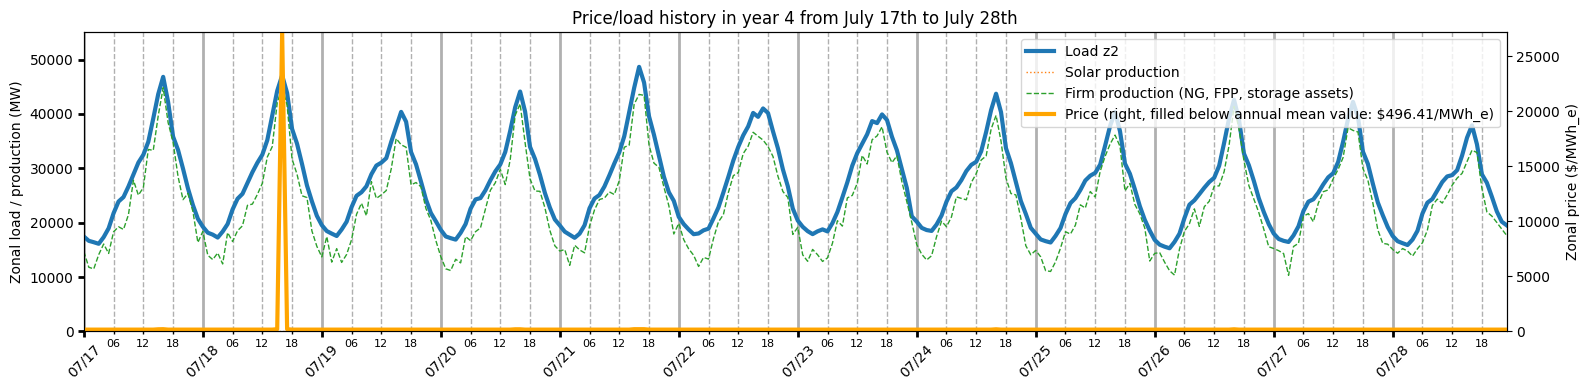

In [846]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.dates as mdates

ref_date = pd.to_datetime('01/01/2050')

start_date = ref_date + pd.DateOffset(hours=start_tick)
end_date = ref_date + pd.DateOffset(hours=end_tick)

x_data = pd.date_range(start=start_date, end=end_date, freq='h', inclusive='left')
x_labels = [date.strftime('%m/%d - %H%p') for date in x_data]
x_label_title = [x_data[i].strftime('%B %dth') for i in [0, -1]]

y = target_y

tech_to_plot = {}


if Temporal_segment_bool:
    fig, ax = plt.subplots(nrows=1,ncols=1, figsize =(16,4))
    line_list = []
    line_label_list = []

    if Load_z2_plot_bool:
        load_line, = ax.plot(x_data, dict_df_years[y]["Load z2"][start_tick:end_tick], lw=3)
        line_list.append(load_line)
        line_label_list.append("Load z2")

    solar_production = dict_df_years[y]["Solar PV z2"][start_tick:end_tick] + dict_df_years[y]["Comm solar PV z2"][start_tick:end_tick] + dict_df_years[y]["Res solar PV z2"][start_tick:end_tick]
    
    if Solar_z2_plot_bool:
        solar_line, = ax.plot(x_data, solar_production, ls=":", lw=1)
        line_list.append(solar_line)
        line_label_list.append("Solar production")

    wind_production = dict_df_years[y]["Onshore wind z2"][start_tick:end_tick] + dict_df_years[y]["Fixed offshore wind z2"][start_tick:end_tick] + dict_df_years[y]["Floating offshore wind z2"][start_tick:end_tick]
    if Wind_z2_plot_bool:
        wind_line, = ax.plot(x_data, wind_production)
        line_list.append(wind_line)
        line_label_list.append("Wind production")

    ror_production = dict_df_years[y]["RoR z2"][start_tick:end_tick]

    VRE_production = solar_production + wind_production + ror_production
    if VRE_z2_plot_bool:
        VRE_line, = ax.plot(x_data, VRE_production, ls="--", lw=1)
        line_list.append(VRE_line)
        line_label_list.append("VRE production")

    storage_production = dict_df_years[y]["Battery flow z2"][start_tick:end_tick] + dict_df_years[y]["PHS flow z2"][start_tick:end_tick]
    if Storage_z2_plot_bool:
        storage_line, = ax.plot(x_data, storage_production)
        line_list.append(storage_line)
        line_label_list.append("Storage production")
    
    firm_production = dict_df_years[y]["Hydro z1"][start_tick:end_tick] - dict_df_years[y]["Load z1"][start_tick:end_tick] + dict_df_years[y]["NG z2"][start_tick:end_tick] + dict_df_years[y]["NG-CCS z2"][start_tick:end_tick] + dict_df_years[y]["Battery flow z2"][start_tick:end_tick] + dict_df_years[y]["PHS flow z2"][start_tick:end_tick] + dict_df_years[y]["Fusion z2"][start_tick:end_tick]
    if Firm_z2_plot_bool:
        firm_line, = ax.plot(x_data, firm_production, ls="--", lw=1)
        line_list.append(firm_line)
        line_label_list.append("Firm production (NG, FPP, storage assets)")

    ax.set_title(f"Price/load history in year {y} from {x_label_title[0]} to {x_label_title[-1]}")
    if Production_plot_bool:
        if Load_z2_plot_bool:
            ax.set_ylabel("Zonal load / production (MW)")
        else:
            ax.set_ylabel("Production (MW)")
    elif Load_z2_plot_bool:
        ax.set_ylabel("Zonal load (MW)")
    # end if
    ax.set_xlim(x_data[0], x_data[-1])

    if Storage_z2_plot_bool:
        ax.set_ylim(-5000, 55000)
    else:
        ax.set_ylim(0, 55000)

    if Price_z2_plot_bool:
        sec_ax=ax.twinx()
        price_line, = sec_ax.plot(x_data, dict_df_years[y]["Price z2"][start_tick:end_tick], color='orange', lw=3)

        mean_annual_price = dict_df_years[y]["Price z2"].mean()
        sec_ax.set_ylim(0,dict_df_years[y]["Price z2"][start_tick:end_tick].max())
        sec_ax.set_ylabel("Zonal price ($/MWh_e)")
        line_list.append(price_line)
        line_label_list.append(f"Price (right, filled below annual mean value: ${mean_annual_price:,.2f}/MWh_e)")

    sec_ax.fill_between(x_data, 0, dict_df_years[y]["Price z2"][start_tick:end_tick], where=(dict_df_years[y]["Price z2"][start_tick:end_tick] <= mean_annual_price), color="orange", alpha=0.3)
    
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

    ax.tick_params(which='major', width=2)
    ax.tick_params(which='major', length=10)
    ax.tick_params(which='major', axis='x', labelrotation=45)

    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H'))
    ax.tick_params(which='minor', width=1)
    ax.tick_params(which='major', length=4)
    ax.tick_params(which='minor', labelsize=8)

    ax.grid(which='major', axis='x', linestyle='-', linewidth=2)
    ax.grid(which='minor', axis='x', linestyle='--', linewidth=1)

    plt.legend(line_list, line_label_list)

    plt.tight_layout()
    plt.xticks(rotation=45)
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

## GenX TES

### GenX TES specs

In [847]:
Gross_fusion_summary = f"{directory}{scenario_selected}/Results/{sub_scenario_name}/fusion/fusion_summary.csv"
Gross_fusion_data = f"{directory}{scenario_selected}/Fusion_data.csv"
Gross_generator_data = f"{directory}{scenario_selected}/Generators_data.csv"

df_fusion_summary = pd.read_csv(Gross_fusion_summary)
df_fusion_data = pd.read_csv(Gross_fusion_data)
df_generators_data = pd.read_csv(Gross_generator_data)

FPP_num = df_fusion_summary["Num Reactors"][0]
FPP_capacity = df_fusion_summary["Single Reactor Thermal Capacity MWt"][0]
FPP_total_capacity = df_fusion_summary["Reactor Thermal Capacity MWt"][0]
FPP_BOP_efficiency = 3412000 / (df_generators_data["Heat_Rate_MMBTU_per_MWh"][12] * 1e6) #0.4

TES_capacity_MWh_th = df_fusion_summary["Thermal Storage Energy Capacity MWht"][0]
TES_dis_capacity_MW_th = df_fusion_summary["Thermal Storage Discharge Capacity MWt"][0]
TES_cha_capacity_MW_th = df_fusion_summary["Thermal Storage Charge Capacity MWt"][0]
# TES_cha_capacity_MW_th = TES_dis_capacity_MW_th
if TES_cha_capacity_MW_th == 0 and TES_dis_capacity_MW_th > 0:
    TES_cha_capacity_MW_th = TES_dis_capacity_MW_th
# end if

TES_capacity_MWh_e = TES_capacity_MWh_th * FPP_BOP_efficiency
TES_dis_capacity_MW_e = TES_dis_capacity_MW_th * FPP_BOP_efficiency
TES_cha_capacity_MW_e = TES_cha_capacity_MW_th * FPP_BOP_efficiency

TES_min_charge_duration = TES_capacity_MWh_e / TES_cha_capacity_MW_e
if TES_dis_capacity_MW_e - TES_cha_capacity_MW_e != 0:
    TES_min_discharge_duration_on = TES_capacity_MWh_e / (TES_dis_capacity_MW_e - TES_cha_capacity_MW_e)
    TES_max_turnover_on = 8760 / (TES_min_charge_duration + TES_min_discharge_duration_on)
else:
    TES_min_discharge_duration_on = np.inf
    TES_max_turnover_on = np.inf
# end if
TES_min_discharge_duration_off = TES_capacity_MWh_e / TES_dis_capacity_MW_e
TES_max_turnover_off = 8760 / (TES_min_charge_duration + TES_min_discharge_duration_off)

TES_eff_ratio_charge = 1
TES_eff_ratio_discharge = df_fusion_data["Therm_Stor_Discharge_Eff_Frac"][12]
TES_eff_ratio = TES_eff_ratio_charge * TES_eff_ratio_discharge
TES_daily_leakage = df_fusion_data["Therm_Stor_Leakage_Daily_Frac"][12]
TES_hourly_leakage_rate = TES_daily_leakage/24

Discount_rate = 0.06
TES_lifetime = 40 #Future of Storage, p.322

CAPEX_MWh_th = 1196.307647 #Corrected Fusion_data.csv
CAPEX_MWh_e = 45*1000 #Table 5.13 Fusion report, annualized cost per MWh_e
CAPEX_MW_e_TES = 375 * 1000 #Table 5.13 Fusion report, annualized cost per MWh_e
CAPEX_MW_e_BoP = 1270 * 1000  #Table 5.13 Fusion report, annualized cost per MWh_e
CAPEX_MW_e = 0*CAPEX_MW_e_TES + CAPEX_MW_e_BoP #Table 5.13 Fusion report, assumming no cost for exchangers

# TES_cost = TES_capacity_MWh_th * CAPEX_MWh_th
# TES_cost = TES_capacity_MWh_e * CAPEX_MWh_e #+ (TES_dis_capacity_MW_e + TES_cha_capacity_MW_e) * CAPEX_MW_e / 2
TES_cost = TES_capacity_MWh_e * CAPEX_MWh_e + (TES_dis_capacity_MW_e - TES_cha_capacity_MW_e) * CAPEX_MW_e
Annualized_TES_cost = (Discount_rate * TES_cost) / (1 - (1 + Discount_rate)**(-TES_lifetime))
TES_total_cost = TES_lifetime * Annualized_TES_cost


print("----------------------- GenX TES SPECIFICATIONS -----------------------")
print(f"{'TES energy capacity:':26s} {f'{TES_capacity_MWh_th:,.2f} MWh_t,':21s} equivalent to {f'{TES_capacity_MWh_e:,.2f}':>12s} MWh_e")
print(f"{'TES discharging capacity:':26s} {f'{TES_dis_capacity_MW_th:,.2f} MW_t,':21s} equivalent to {f'{TES_dis_capacity_MW_e:,.2f}':>12s} MW_e")
print(f"{'TES charging capacity:':26s} {f'{TES_cha_capacity_MW_th:,.2f} MW_t,':21s} equivalent to {f'{TES_cha_capacity_MW_e:,.2f}':>12s} MW_e")
print("")
print(f"TES Boost rate (Discharging/Charging capacities): {TES_dis_capacity_MW_th/TES_cha_capacity_MW_th:.2%}")
print(f"TES net discharge capacity: {TES_dis_capacity_MW_th-TES_cha_capacity_MW_th:,.2f} MW_t equivalent to {TES_dis_capacity_MW_e - TES_cha_capacity_MW_e:,.2f} MW_e")
print("")
if TES_dis_capacity_MW_e - TES_cha_capacity_MW_e != 0:
    print(f"Equivalent min discharging duration (NPP baseload): {f'{TES_min_discharge_duration_on:.2f} hours':>15}")
    print(f"This TES can cycle up to {TES_max_turnover_on:.2f} times per year (with NPP baseload)")
# end if
print(f"Equivalent min discharging duration (NPP offline):  {f'{TES_min_discharge_duration_off:.2f} hours':>15}")
print(f"This TES can cycle up to {TES_max_turnover_off:.2f} times per year (with NPP offline)")
print("")
print(f"Efficiency ratio: {TES_eff_ratio:.2%}")
print(f"Daily leakage rate: {TES_daily_leakage:.2%}/day of energy stored, equivalent to {TES_hourly_leakage_rate:.2%}/hour")
print("")
print(f"TES upfront cost:          {f'$ {TES_cost:,.2f}':>20}")
print(f"TES annualized cost:       {f'$ {Annualized_TES_cost:,.2f}':>20} /yr...........assuming {TES_lifetime} years @ {Discount_rate:.1%}")
print(f"Total TES annualized cost: {f'$ {TES_total_cost:,.2f}':>20}...............assuming {TES_lifetime} years @ {Discount_rate:.1%}")

----------------------- GenX TES SPECIFICATIONS -----------------------
TES energy capacity:       173,391.53 MWh_t,     equivalent to    69,356.61 MWh_e
TES discharging capacity:  124,755.99 MW_t,      equivalent to    49,902.40 MW_e
TES charging capacity:     121,090.03 MW_t,      equivalent to    48,436.01 MW_e

TES Boost rate (Discharging/Charging capacities): 103.03%
TES net discharge capacity: 3,665.96 MW_t equivalent to 1,466.38 MW_e

Equivalent min discharging duration (NPP baseload):     47.30 hours
This TES can cycle up to 179.77 times per year (with NPP baseload)
Equivalent min discharging duration (NPP offline):       1.39 hours
This TES can cycle up to 3104.44 times per year (with NPP offline)

Efficiency ratio: 100.00%
Daily leakage rate: 2.00%/day of energy stored, equivalent to 0.08%/hour

TES upfront cost:            $ 4,983,353,089.86
TES annualized cost:           $ 331,201,300.39 /yr...........assuming 40 years @ 6.0%
Total TES annualized cost:  $ 13,248,052,015.48.

### Other (data loading, FPP operations, graphs)

In [848]:
energy_threshold = 0 # min MWh available for storage
FPP_dict = {}

start_tick = 0 #31*24
end_tick = 8760 #31*24+28*24+1

price_threshold = 0 # $/MWh_e

i = 0

for y in year_list:
    FPP_offline_hours_y = int((dict_df_years[y]["Reactor output MWht"] <= 1).sum())
    FPP_energy_below_nameplate_capacity_y = float(((FPP_num * FPP_capacity - dict_df_years[y]["Reactor output MWht"]) * (dict_df_years[y]["Reactor output MWht"] > 1)).sum())
    FPP_full_power_hours_y = int(((FPP_num * FPP_capacity - dict_df_years[y]["Reactor output MWht"]) <= 1).sum())
    FPP_capacity_factor_y = float(dict_df_years[y]["Reactor output MWht"].sum()/(FPP_num*FPP_capacity*8760))

    FPP_dict.update({y : {"FPP load factor" : FPP_capacity_factor_y, "FPP offline hours (h)" : FPP_offline_hours_y, "Energy storable (MWh)" : FPP_energy_below_nameplate_capacity_y, "FPP full-capacity hours (h)" : FPP_full_power_hours_y}})
# end for

FPP_df = pd.DataFrame(FPP_dict)

pd.options.display.float_format = '{:,.2f}'.format

print(FPP_df.transpose().mean())

FPP load factor                         0.64
FPP offline hours (h)                   0.00
Energy storable (MWh)         382,019,652.60
FPP full-capacity hours (h)           742.00
dtype: float64


#### Data loading

In [849]:
Gross_capacity = f"{directory}{scenario_selected}/Results/{sub_scenario_name}/capacity.csv"
df_capacity = pd.read_csv(Gross_capacity)

Battery_energy_EndCap = df_capacity["EndEnergyCap"][9]
PHS_energy_EndCap = df_capacity["EndEnergyCap"][11]
TES_energy_EndCap = TES_capacity_MWh_e

Battery_discharge_EndCap = df_capacity["EndCap"][9]
PHS_discharge_EndCap = df_capacity["EndCap"][11]
TES_discharge_EndCap = TES_dis_capacity_MW_e

capacity_energy = {"Battery" : Battery_energy_EndCap, "PHS" : PHS_energy_EndCap, "TES" : TES_energy_EndCap}
capacity_discharge = {"Battery" : Battery_discharge_EndCap, "PHS" : PHS_discharge_EndCap, "TES" : TES_discharge_EndCap}

eff_up_dict = {"Battery" : df_generators_data["Eff_Up"][9], "PHS" : df_generators_data["Eff_Up"][11], "TES" : TES_eff_ratio_charge}
eff_down_dict = {"Battery" : df_generators_data["Eff_Down"][9], "PHS" : df_generators_data["Eff_Down"][11], "TES" : TES_eff_ratio_discharge}

#### Profit analysis

In [850]:
i = 0

start_tick = 0 #31*24
end_tick = 8760 #31*24+28*24+1

tech_list = ["Battery", "PHS", "TES"]

for y in year_list:
        for tech in tech_list:
            
            # {tech} flow z2 is in MWh_e. TES powerflow is given in MWh_th and should be separated to be converted
            # Note that the "TES charge price" is the price that the energy would have been valued on the market at the storage timestep, hence it has to account for the BOP efficiency ratio
            if tech != "TES":
                dict_df_years[y][f"{tech} flow z2"] = dict_df_years[y][f"{tech} z2"].diff()
            else: 
                dict_df_years[y][f"{tech} flow z2"] = -dict_df_years[y]["TES net discharge MWht"] * FPP_BOP_efficiency
                dict_df_years[y][f"{tech} flow z2"].loc[dict_df_years[y][f"{tech} flow z2"] < 0] *= eff_down_dict['TES']
            # end if
            
            dict_df_years[y][f"{tech} charge flow"] = (dict_df_years[y][f"{tech} flow z2"] * (dict_df_years[y][f"{tech} flow z2"] > 0)).replace({0 : np.nan})
            dict_df_years[y][f"{tech} discharge flow"] = (dict_df_years[y][f"{tech} flow z2"] * (dict_df_years[y][f"{tech} flow z2"] < 0)).replace({0 : np.nan})

            dict_df_years[y][f"{tech} charge cumflow"] = (dict_df_years[y][f"{tech} flow z2"] * (dict_df_years[y][f"{tech} flow z2"] > 0)).replace({0 : np.nan}).cumsum()
            dict_df_years[y][f"{tech} discharge cumflow"] = (dict_df_years[y][f"{tech} flow z2"] * (dict_df_years[y][f"{tech} flow z2"] < 0)).replace({0 : np.nan}).cumsum()
            
            dict_df_years[y][f"{tech} charge price"] = (dict_df_years[y]["Price z2"] * (dict_df_years[y][f"{tech} flow z2"] > 0)).replace({0 : np.nan})
            dict_df_years[y][f"{tech} discharge price"] = (dict_df_years[y]["Price z2"] * (dict_df_years[y][f"{tech} flow z2"] < 0)).replace({0 : np.nan})
            
            dict_df_years[y][f"{tech} profit"] = - dict_df_years[y][f"{tech} flow z2"] * dict_df_years[y]["Price z2"]
            
            dict_df_years[y][f"{tech} cumulated profit"] = dict_df_years[y][f"{tech} profit"].cumsum()
        # end for

        Total_storage_profit = 0
        for tech in tech_list:
            Total_storage_profit += dict_df_years[y][f"{tech} cumulated profit"]
        # end for

        dict_df_years[y][f"Storage cumulated profit"] = Total_storage_profit
# end for

C:\Users\INVITE\AppData\Local\Temp\ipykernel_8816\3588163554.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dict_df_years[y][f"{tech} flow z2"].loc[dict_df_years[y][f"{tech} flow z2"] < 0] *= eff_down_dict['TES']


In [851]:
if Storage_profit_profile_bool:
    fig = plt.figure(figsize=(20,30))
    ax1 = plt.subplot(411)
    ax2 = plt.subplot(412)
    ax3 = plt.subplot(413)
    ax4 = plt.subplot(414)

    dict_ax = {ax1 : "Battery", ax2 : "PHS", ax3 : "TES", ax4 : "Storage"}

    for y in year_list:
        for ax in [ax1, ax2, ax3, ax4]:
            tech = dict_ax[ax]
            ax.plot(dict_df_years[y][f'{tech} cumulated profit']/dict_df_years[y][f'{tech} cumulated profit'][8759], label=f'{tech} profit in year {y} : ${dict_df_years[y][f"{tech} cumulated profit"][8759]:.2e}')
            ax.set_xlabel("Time (h)")
            ax.set_ylabel(f"{tech} profit (normalized to the yearly profit)")
            ax.set_title(f"Profit made from {tech}")


        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  Plots ready for year {y}! Battery profit for year {y} : {dict_df_years[y]['Battery profit'].sum()}" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        i += 1
    # end for

    for ax in [ax1, ax2, ax3, ax4]:
        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

        # Put a legend to the right of the current axis
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    # end for

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlim(start_tick,end_tick)
    # end for
    plt.tight_layout()
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

Activate the boolean filter to calculate and display the plot


#### Charging/discharging price distributions

In [852]:
if Price_distribution_bool:
    fig = plt.figure(figsize=(20,20))
    ax1 = plt.subplot(311)
    ax2 = plt.subplot(312)
    ax3 = plt.subplot(313)

    dict_ax = {ax1 : "Battery", ax2 : "PHS", ax3 : "TES"}
    
    for ax in [ax1, ax2, ax3]:
            tech = dict_ax[ax]

            tech_charging_prices_df = pd.concat([pd.DataFrame(dict_df_years[y][f"{tech} charge price in year {y}"]) for y in year_list], axis=1)
            tech_discharging_prices_df = pd.concat([dict_df_years[y][f"{tech} discharge price in year {y}"] for y in year_list], axis=1)

            tech_charging_prices_df.plot.box(ax=ax, positions=[2*i for i in range(len(tech_charging_prices_df.columns))], showfliers=False)
            tech_discharging_prices_df.plot.box(ax=ax, title=f"{tech} charging/discharging prices", ylabel="Price ($/MWh)", rot=90, positions=[2*i+1 for i in range(len(tech_discharging_prices_df.columns))], showfliers=False)
            ax.set_ylim(0,200)
            ax.set_xticks(range(0, 2*len(tech_charging_prices_df.columns)))
            xlabels = []
            for y in year_list:
                xlabels.append(f"{tech} charge price in year {y}")
                xlabels.append(f"{tech} discharge price in year {y}")
            #end for

            ax.set_xticklabels(xlabels)

    plt.tight_layout()
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

Activate the boolean filter to calculate and display the plot


In [853]:
y = 4

<Axes: >

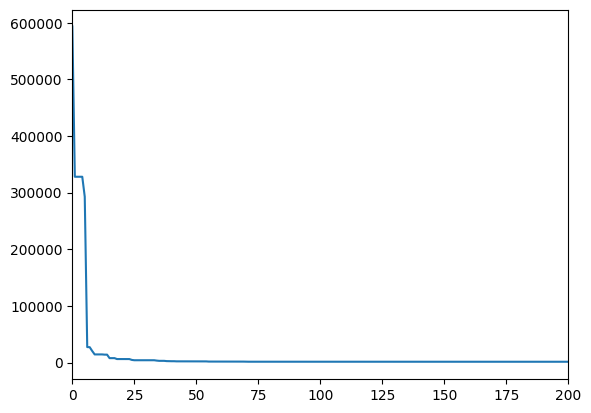

In [854]:
dict_df_years[y]["Price z2"].sort_values(ascending=False, ignore_index=True).plot(xlim=(0,200))

In [855]:
index_peak = dict_df_years[y]["Price z2"][dict_df_years[y]["Price z2"] > 10000].index
print(dict_df_years[y]["Price z2"][index_peak].describe())

count        15.00
mean    157,288.15
std     189,096.86
min      14,001.18
25%      14,395.21
50%      27,176.25
75%     328,106.90
max     593,455.76
Name: Price z2, dtype: float64


In [856]:
dict_df_years[y][f"{tech} flow z2"][index_peak].describe()

count       15.00
mean    -1,466.38
std          0.00
min     -1,466.38
25%     -1,466.38
50%     -1,466.38
75%     -1,466.38
max     -1,466.38
Name: TES flow z2, dtype: float64

In [857]:
print(f"Scarcity hours profit: ${-(dict_df_years[y][f'{tech} flow z2'][index_peak] * dict_df_years[y]['Price z2'][index_peak]).sum():,.2f}")

Scarcity hours profit: $3,459,668,387.75


In [858]:
print(f"Annual profit: ${-(dict_df_years[y][f'{tech} flow z2'][:] * dict_df_years[y]['Price z2'][:]).sum():,.2f}")

Annual profit: $4,087,992,231.56


### GenX TES performance

In [859]:
profit_storage = {}

for y in year_list:
    profit_storage_y = {}
    for tech in ["Battery", "PHS", "TES"]:
        # if tech != "TES":
        #     discharged_energy_y_tech = (dict_df_years[y][f"{tech} flow z2"] * (dict_df_years[y][f"{tech} flow z2"] < 0)).sum()
        # else:
        #     discharged_energy_y_tech = -(dict_df_years[y][f"{tech} discharge MWht"] * FPP_BOP_efficiency).sum()
        # #end if
        discharged_energy_y_tech = (dict_df_years[y][f"{tech} flow z2"] * (dict_df_years[y][f"{tech} flow z2"] < 0)).sum()

        profit_storage_y.update({f"{tech}" : 
                                 {f"Annual profit ($)" : float(dict_df_years[y][f"{tech} cumulated profit"][8759]),
                                 f"Net annual profit ($)" : float(dict_df_years[y][f"{tech} cumulated profit"][8759] - Annualized_TES_cost),
                                 f"Annual discharge (MWh_e)" : -float(discharged_energy_y_tech),
                                 f"Annual discharge (full-cycles)" : -float(discharged_energy_y_tech/capacity_energy[tech]),
                                 f"Average turnover profit ($/MWh_e)" : -float(dict_df_years[y][f"{tech} cumulated profit"][8759])/float(discharged_energy_y_tech),
                                 f"Average turnover profit ($ per full-cycle)" : -float(dict_df_years[y][f"{tech} cumulated profit"][8759])/float(discharged_energy_y_tech)*float(capacity_energy[tech])}})
    # end for
    profit_storage.update({f"Year {y}":profit_storage_y})
# end for

profit_storage_y_tech = {(outerKey, innerKey): values for outerKey, innerDict in profit_storage.items() for innerKey, values in innerDict.items()}
profit_storage_tech_y = {(innerKey, outerKey): values for outerKey, innerDict in profit_storage.items() for innerKey, values in innerDict.items()}


profit_storage_y_tech_df = pd.DataFrame(data=profit_storage_y_tech)
profit_storage_tech_y_df = pd.DataFrame(data=profit_storage_tech_y)
pd.set_option('display.float_format', '{:.2f}'.format)

# print(profit_storage_y_tech_df)

# print(profit_storage_tech_y_df["TES"])
print(profit_storage_tech_y_df["TES"].transpose().describe())

       Annual profit ($)  Net annual profit ($)  Annual discharge (MWh_e)  \
count               1.00                   1.00                      1.00   
mean       4087992231.56          3756790931.18                 782986.92   
std                  NaN                    NaN                       NaN   
min        4087992231.56          3756790931.18                 782986.92   
25%        4087992231.56          3756790931.18                 782986.92   
50%        4087992231.56          3756790931.18                 782986.92   
75%        4087992231.56          3756790931.18                 782986.92   
max        4087992231.56          3756790931.18                 782986.92   

       Annual discharge (full-cycles)  Average turnover profit ($/MWh_e)  \
count                            1.00                               1.00   
mean                            11.29                            5221.02   
std                               NaN                                NaN   
mi

In [860]:
TES_annual_turnover = profit_storage_tech_y_df["TES"].transpose()['Annual discharge (full-cycles)']
TES_mean_turnover_count = TES_annual_turnover.mean()
Spread_goal_per_turnover = TES_total_cost/(TES_mean_turnover_count*TES_lifetime)

TES_mean_turnover_profit = profit_storage_tech_y_df["TES"].transpose()['Average turnover profit ($ per full-cycle)'].mean()
TES_mean_spread = profit_storage_tech_y_df["TES"].transpose()['Average turnover profit ($/MWh_e)'].mean()

print(f"Assuming that the TES capital costs should be annualized on {TES_lifetime} years @ {Discount_rate:.2%}:")
print(f"   the TES should capture at least      ${Spread_goal_per_turnover:<15,.2f}/turnover or   ${Spread_goal_per_turnover/TES_capacity_MWh_e:>8,.2f}/MWh_e discharged")
print(f"   the TES is effectively capturing     ${TES_mean_turnover_profit:<15,.2f}/turnover or   ${TES_mean_spread:>8,.2f}/MWh_e discharged")

Assuming that the TES capital costs should be annualized on 40 years @ 6.00%:
   the TES should capture at least      $29,337,655.30  /turnover or   $  423.00/MWh_e discharged
   the TES is effectively capturing     $362,112,427.76 /turnover or   $5,221.02/MWh_e discharged


### GenX SoC profile

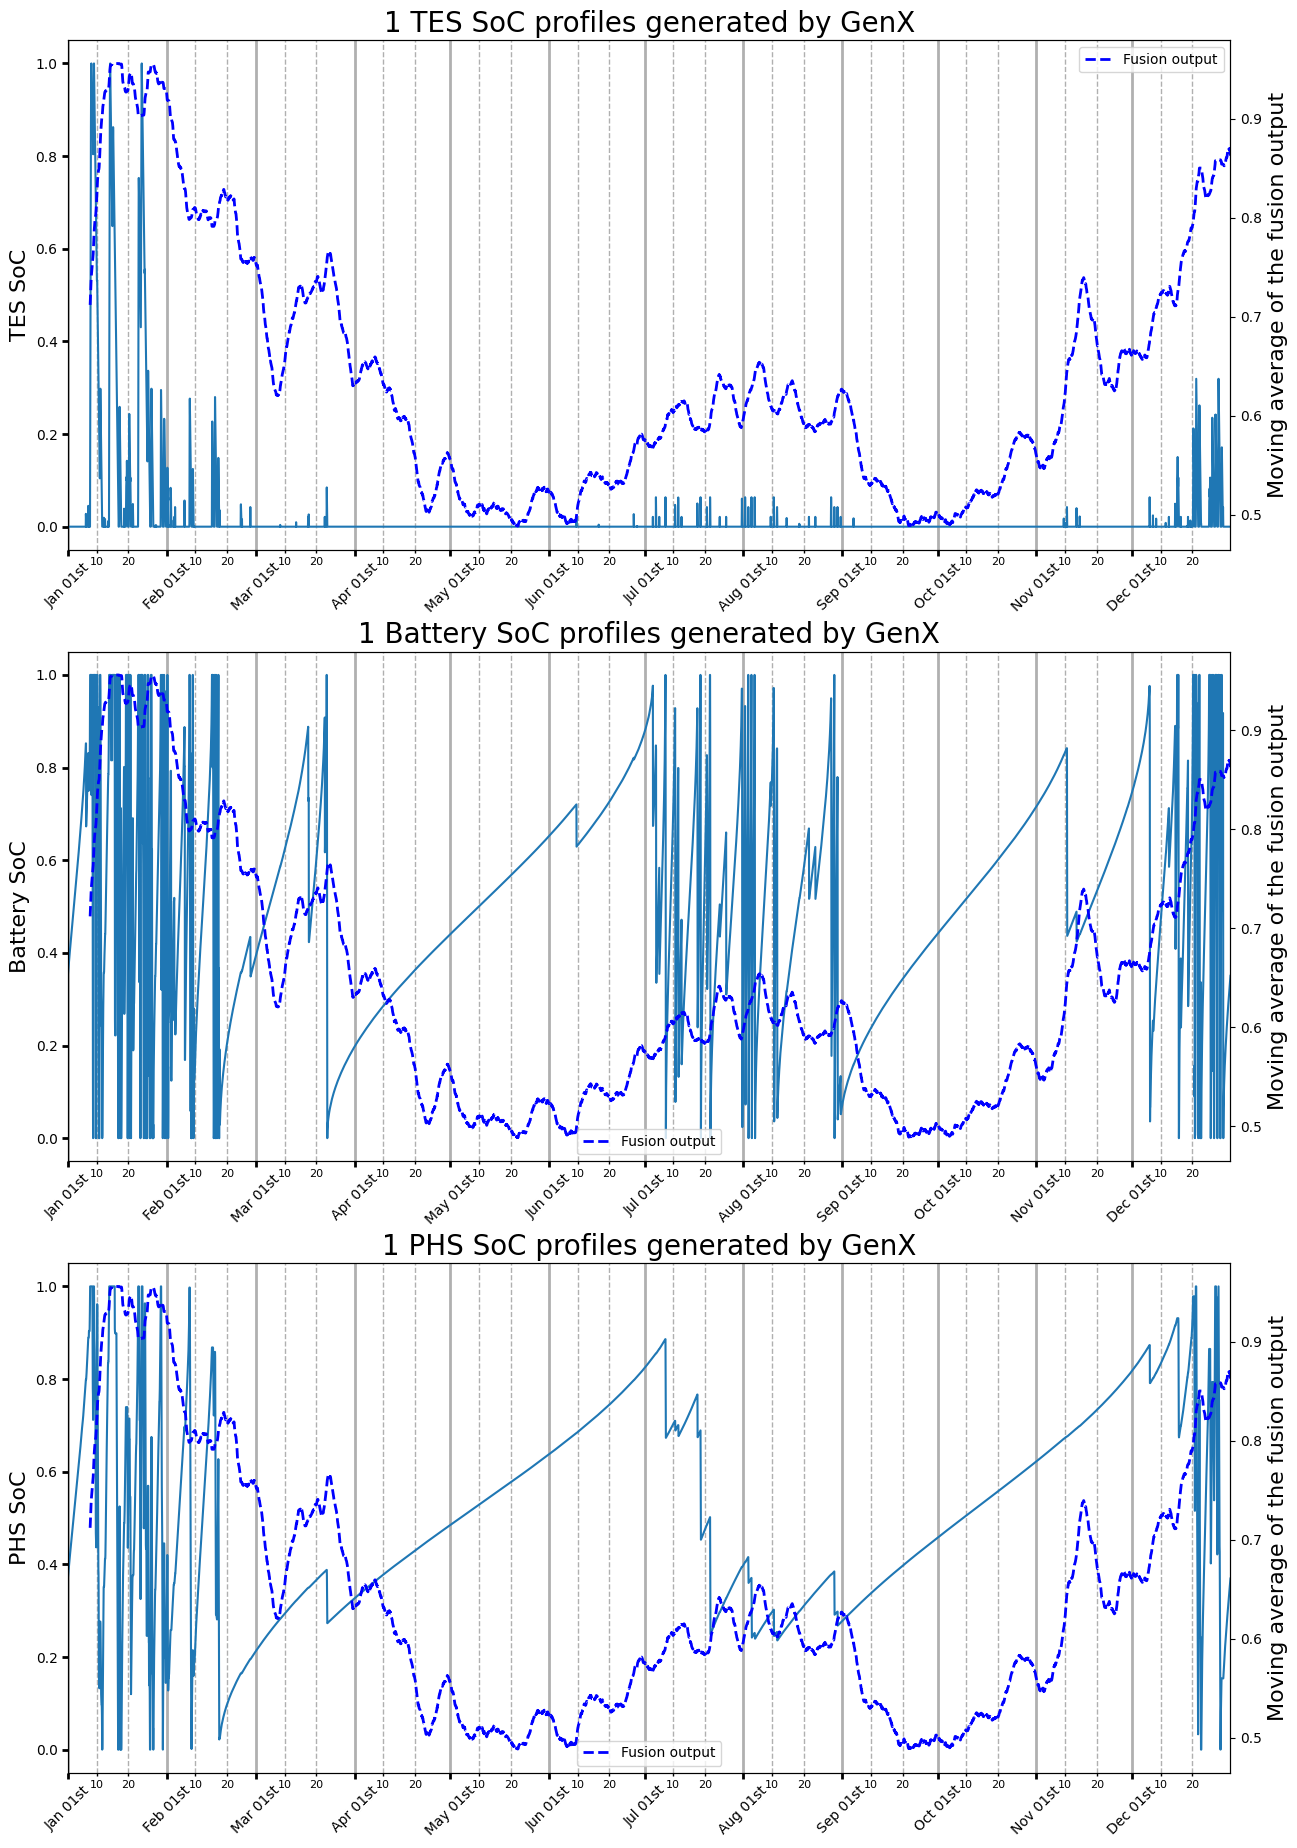

In [861]:
if TES_normalized_level_bool:

    option_list = ['Load', 'Firm', 'Fusion', None] # Default below is 'Fusion'
    option = option_list[2]

    fig = plt.figure(figsize=(15,22.5))
    ax1 = plt.subplot(311)
    ax2 = plt.subplot(312)
    ax3 = plt.subplot(313)

    ax1bis = ax1.twinx()
    ax2bis = ax2.twinx()
    ax3bis = ax3.twinx()

    ax_list = [ax1, ax2, ax3]
    axbis_list = [ax1bis, ax2bis, ax3bis]
    ax_tech_dict = {ax1 : "TES", ax2 : "Battery", ax3 : "PHS"}
    ax_soc_dict = {ax1 : "TES level MWht", ax2 : "Battery z2", ax3 : "PHS z2"}
    ax_capa_energy_dict = {ax1 : TES_capacity_MWh_th, ax2 : capacity_energy["Battery"], ax3 : capacity_energy["PHS"]}

    start_tick = 0#480 #31*24
    end_tick = 8760#720 #31*24+28*24+1

    ref_date = pd.to_datetime('01/01/2050')

    start_date = ref_date + pd.DateOffset(hours=start_tick)
    end_date = ref_date + pd.DateOffset(hours=end_tick)

    x_data = pd.date_range(start=start_date, end=end_date, freq='h', inclusive='left')
    x_data_8760 = [(date - ref_date).total_seconds()/3600 for date in x_data]

    x_labels = [date.strftime('%b %d') for date in x_data]
    x_label_title = [x_data[i].strftime('%B %dth') for i in [0, -1]]

    for y in year_list:
        for ax in ax_list:
            ax.plot(x_data, dict_df_years[y][ax_soc_dict[ax]][x_data_8760] / (ax_capa_energy_dict[ax]))
        # end for ax
    # end for y

    # hourly_fusion_production = pd.concat([pd.DataFrame((dict_df_years[y]["Fusion z2"][start_tick:end_tick]).rename(f"Fusion {y}")) for y in year_list], axis=1).transpose()
    hourly_fusion_production = pd.concat([pd.DataFrame((dict_df_years[y]["Reactor output MWht"][start_tick:end_tick])) for y in year_list], axis=1).transpose() / FPP_total_capacity
    
    if option == 'Load':
        hourly_load_df = pd.concat([pd.DataFrame(dict_df_years[y]['Load z2'][x_data_8760].rename(f"Load {y}")) for y in year_list], axis=1).transpose()
        contextual_df = hourly_load_df
        axbistitle = 'Moving average of the load (MWh_e)'
        legend = 'Load'
    elif option == 'Firm':
        hourly_firm_production = pd.concat([pd.DataFrame((
                                                        dict_df_years[y]["Hydro z1"][start_tick:end_tick]
                                                        - dict_df_years[y]["Load z1"][start_tick:end_tick]
                                                        + dict_df_years[y]["NG z2"][start_tick:end_tick]
                                                        + dict_df_years[y]["NG-CCS z2"][start_tick:end_tick]
                                                        + dict_df_years[y]["Battery flow z2"][start_tick:end_tick]
                                                        + dict_df_years[y]["PHS flow z2"][start_tick:end_tick]
                                                        + dict_df_years[y]["Fusion z2"][start_tick:end_tick]
                                                        ).rename(f"Net load {y}")) for y in year_list], axis=1).transpose()
        contextual_df = hourly_firm_production
        axbistitle = 'Moving average of the firm production (MWh_e)'
        legend = 'Firm output'
    else:
        contextual_df = hourly_fusion_production
        axbistitle = 'Moving average of the fusion output'
        legend = 'Fusion output'
    # end if

    if option != None:
        for axbis in axbis_list:
            contextual_line, = axbis.plot(x_data, contextual_df.sum().rolling(24*7).mean()/nb_years, ls='--', color='b', lw=2)
            axbis.set_ylabel(axbistitle, fontsize=16)
        # end for
    # end if

    for ax in ax_list:
        ax.set_xlim(x_data[0], x_data[-1])

        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %dst'))

        ax.tick_params(which='major', width=2)
        ax.tick_params(which='major', length=10)
        ax.tick_params(which='major', axis='x', labelrotation=45)

        ax.xaxis.set_minor_locator(mdates.DayLocator(bymonthday=[10,20]))
        ax.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))
        ax.tick_params(which='minor', width=1)
        ax.tick_params(which='major', length=4)
        ax.tick_params(which='minor', labelsize=8)

        ax.grid(which='major', axis='x', linestyle='-', linewidth=2)
        ax.grid(which='minor', axis='x', linestyle='--', linewidth=1)

        ax.set_title(f"{nb_years} {ax_tech_dict[ax]} SoC profiles generated by GenX", fontsize=20)
        ax.set_ylabel(f"{ax_tech_dict[ax]} SoC", fontsize=16)

        ax.legend([contextual_line], [legend])
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

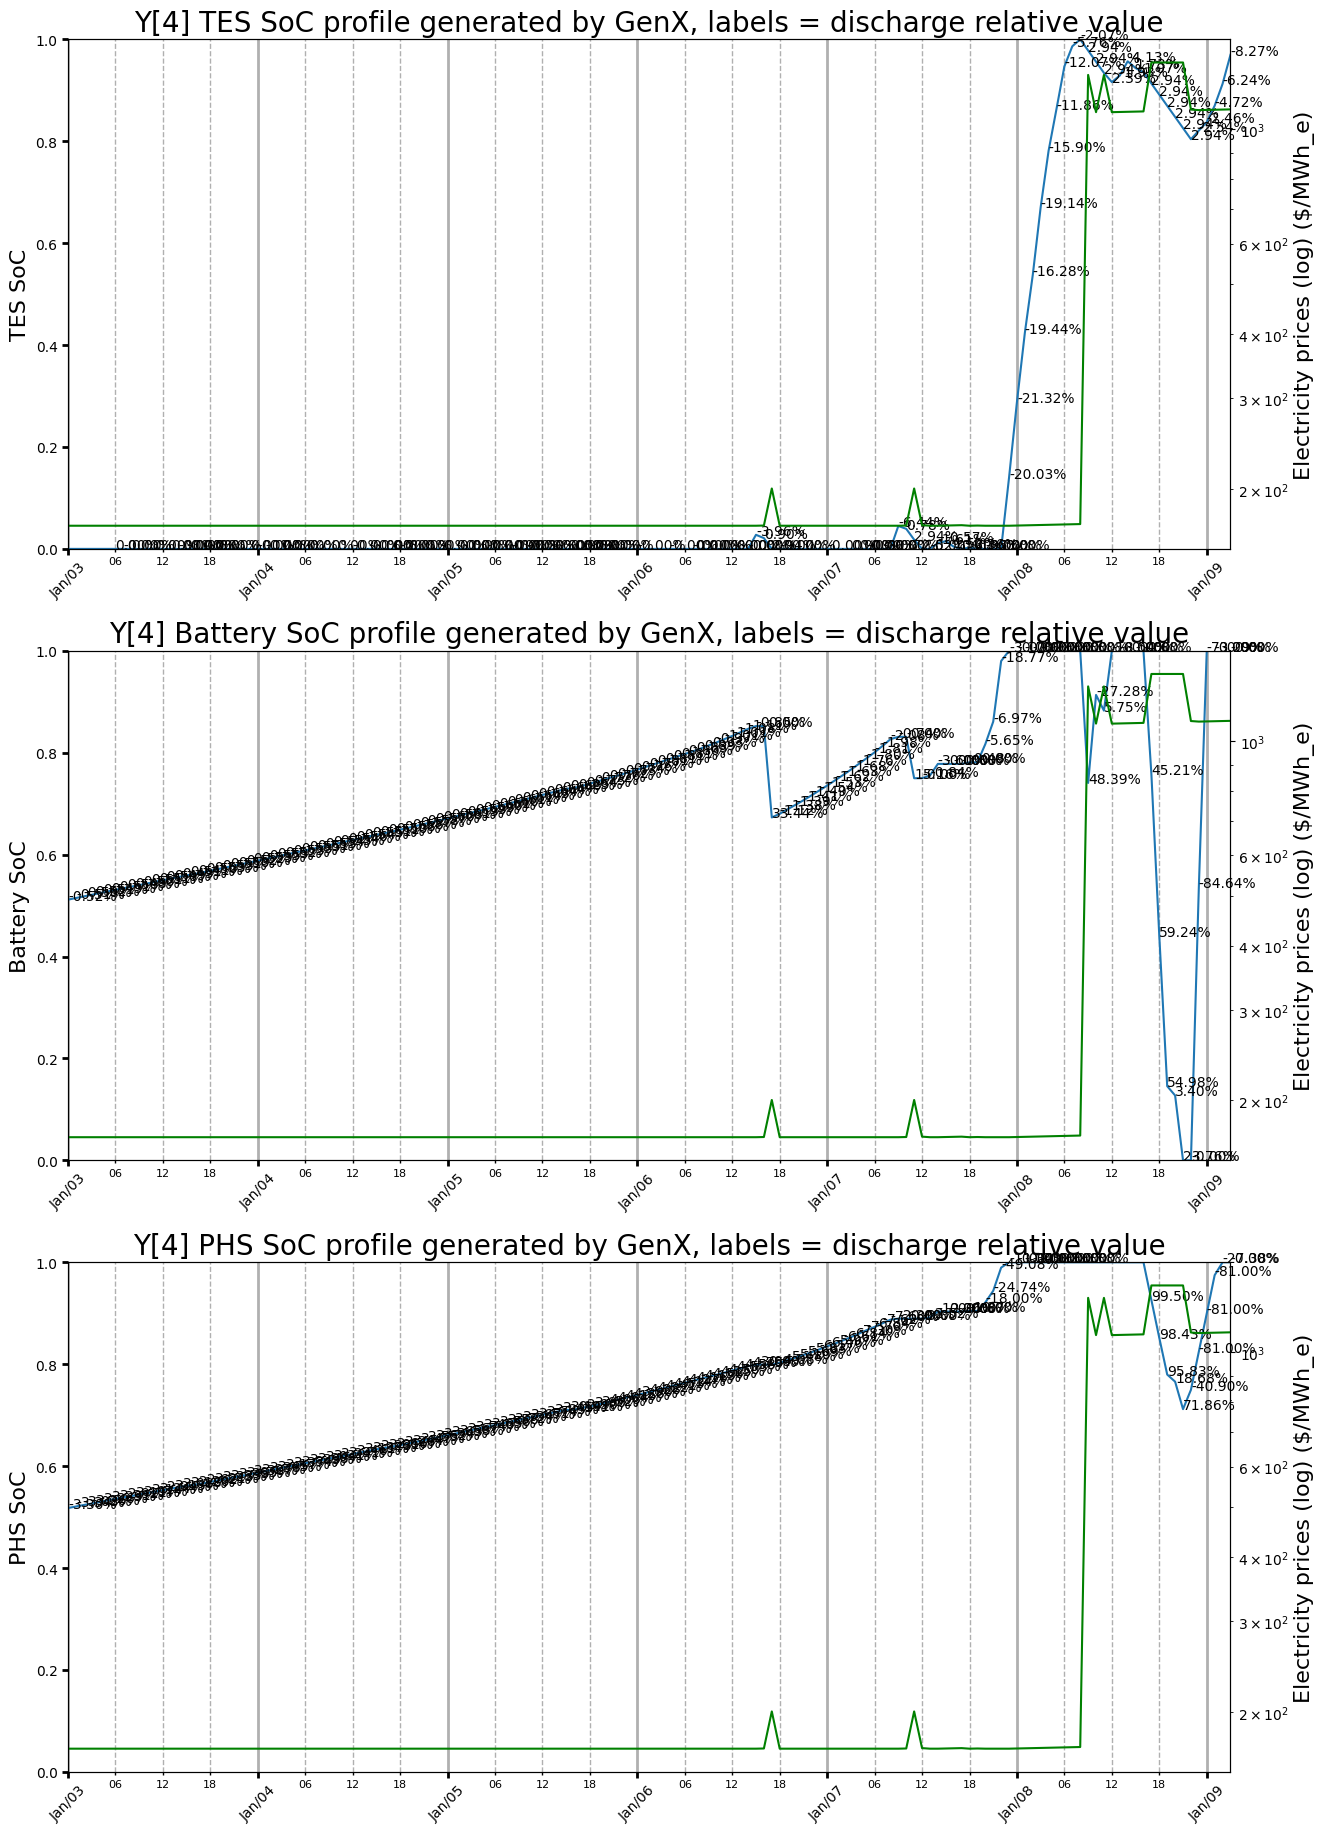

In [862]:
if TES_normalized_level_bool:

    LOCAL_YEAR_LIST = year_list[:1]#[15]#[i for i in range(1,20+1)]
    LOCAL_X_START = 48
    LOCAL_X_END = LOCAL_X_START + 148

    option_list2 = ['Prices', None, 'Fusion'] # Default is Fusion below
    option2 = option_list2[0]

    fig = plt.figure(figsize=(15,22.5))
    ax1 = plt.subplot(311)
    ax2 = plt.subplot(312)
    ax3 = plt.subplot(313)

    ax_list = [ax1, ax2, ax3]
    axbis_dict = {}

    if option2 == 'Prices':
        for ax in ax_list:
            axbis = ax.twinx()
            axbis_dict.update({ax:axbis})
            axbis.set_yscale('log')
            axbis.set_ylabel(f"Electricity prices (log) ($/MWh_e)", fontsize=16)
        # end for
    # end if
    
    ax_tech_dict = {ax1 : "TES", ax2 : "Battery", ax3 : "PHS"}
    ax_soc_dict = {ax1 : "TES level MWht", ax2 : "Battery z2", ax3 : "PHS z2"}
    ax_capa_energy_dict = {ax1 : TES_capacity_MWh_th, ax2 : capacity_energy["Battery"], ax3 : capacity_energy["PHS"]}
    ax_capa_discharge_dict = {ax1 : TES_dis_capacity_MW_th, ax2 : -capacity_discharge["Battery"], ax3 : -capacity_discharge["PHS"]}
    ax_capa_charge_dict = {ax1 : TES_cha_capacity_MW_th, ax2 : -capacity_discharge["Battery"], ax3 : -capacity_discharge["PHS"]}    
    ax_netdisch_dict = {ax1 : "TES net discharge MWht", ax2 : "Battery flow z2", ax3 : "PHS flow z2"}

    label_threshold = .0

    start_tick = LOCAL_X_START
    end_tick = LOCAL_X_END

    ref_date = pd.to_datetime('01/01/2050')

    start_date = ref_date + pd.DateOffset(hours=start_tick)
    end_date = ref_date + pd.DateOffset(hours=end_tick)

    x_data = pd.date_range(start=start_date, end=end_date, freq='h', inclusive='left')
    x_data_8760 = [(date - ref_date).total_seconds()/3600 for date in x_data]

    x_labels = [date.strftime('%b %d') for date in x_data]
    x_label_title = [x_data[i].strftime('%B %dth') for i in [0, -1]]

    for y in LOCAL_YEAR_LIST:
        for ax in ax_list:
            ax.plot(x_data, dict_df_years[y][ax_soc_dict[ax]][x_data_8760] / (ax_capa_energy_dict[ax]))

            for xy in zip(x_data, dict_df_years[y][ax_soc_dict[ax]][x_data_8760] / (ax_capa_energy_dict[ax])):
                label_y = dict_df_years[y][ax_netdisch_dict[ax]][(xy[0]-ref_date).total_seconds()/3600]

                if label_y < 0:
                    # Charging efficiency should be applied
                    label_y /= eff_up_dict[ax_tech_dict[ax]]
                    label_y /= (ax_capa_charge_dict[ax])
                elif label_y > 0:
                    # Disharging efficiency should be applied
                    label_y *= eff_down_dict[ax_tech_dict[ax]]
                    label_y /= (ax_capa_discharge_dict[ax])
                # end if

                if abs(label_y) > label_threshold:
                    ax.annotate(f'{label_y:.2%}', xy=xy, textcoords='data')
                # end if
            # end for xy
            if option2 == 'Prices':
                axbis_dict[ax].plot(x_data, dict_df_years[y]["Price z2"][x_data_8760], color='g')
            elif option2 != None:
                ax.plot(x_data, hourly_fusion_production[x_data_8760].transpose(), lw=2)
            # end if
        # end for ax
    # end for y

    for ax in ax_list:
        ax.set_xlim(x_data[0], x_data[-1])
        ax.set_ylim(0,1)

        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%d'))

        ax.tick_params(which='major', width=2)
        ax.tick_params(which='major', length=10)
        ax.tick_params(which='major', axis='x', labelrotation=45)

        ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
        ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H'))
        ax.tick_params(which='minor', width=1)
        ax.tick_params(which='major', length=4)
        ax.tick_params(which='minor', labelsize=8)

        ax.grid(which='major', axis='x', linestyle='-', linewidth=2)
        ax.grid(which='minor', axis='x', linestyle='--', linewidth=1)

        ax.set_title(f"Y{LOCAL_YEAR_LIST} {ax_tech_dict[ax]} SoC profile generated by GenX, labels = discharge relative value", fontsize=20)
        ax.set_ylabel(f"{ax_tech_dict[ax]} SoC", fontsize=16)
    # end for ax
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

### GenX TES business model

In [863]:
net_charging_threshold = .1 # MWh_t
net_discharging_threshold = .1 # MWh_t

hours_charging = 0
hours_discharging = 0

hours_net_charging = 0
hours_net_discharging = 0

net_charged_energy = 0
net_discharged_energy = 0

max_net_charging_rate = 0
max_net_discharging_rate = 0

for y in year_list:
    hours_charging += (dict_df_years[y]["TES net discharge MWht"] < 0).sum()
    hours_discharging += (dict_df_years[y]["TES net discharge MWht"] > 0).sum()
    
    hours_net_charging += (dict_df_years[y]["TES net discharge MWht"] < -net_charging_threshold).sum()
    hours_net_discharging += (dict_df_years[y]["TES net discharge MWht"] > net_discharging_threshold).sum()

    net_charged_energy += -((dict_df_years[y]["TES net discharge MWht"]) * (dict_df_years[y]["TES net discharge MWht"] < -net_charging_threshold)).sum()
    net_discharged_energy += ((dict_df_years[y]["TES net discharge MWht"]) * (dict_df_years[y]["TES net discharge MWht"] > net_discharging_threshold)).sum()

    max_net_charging_rate = max(max_net_charging_rate, -((dict_df_years[y]["TES net discharge MWht"]) * (dict_df_years[y]["TES net discharge MWht"] < -net_charging_threshold)).min())
    max_net_discharging_rate = max(max_net_discharging_rate, ((dict_df_years[y]["TES net discharge MWht"]) * (dict_df_years[y]["TES net discharge MWht"] > net_discharging_threshold)).max())
# end for

average_net_charging_rate = net_charged_energy / hours_net_charging
average_net_discharging_rate = net_discharged_energy / hours_net_discharging

print("----------------------- GenX TES OPERATIONS -----------------------")
line1_1 = f"The TES is cycling an average {TES_mean_turnover_count:.2f} full-cycles/year "
line1_2 = f"({TES_mean_turnover_count/TES_max_turnover_off:.2%} of max with NPP offline)"
print(f"{line1_1}{line1_2}")
if TES_dis_capacity_MW_e - TES_cha_capacity_MW_e != 0:
    print(f"{' ' * (len(line1_1)-3)}or ({TES_mean_turnover_count/TES_max_turnover_on:.2%} of max with NPP baseload)")
# end if
print("")
print(f"TES is net charging during {hours_net_charging:,} hours (above {net_charging_threshold:.2%} of charging capacity) out of {hours_charging:,} hours")
print(f"Average net charging rate is {average_net_charging_rate:,.2f} MW_th ({average_net_charging_rate/TES_cha_capacity_MW_th:.2%} of {TES_cha_capacity_MW_th:,.2f} MW_th)")
print(f"Maximum net charging rate is {max_net_charging_rate:,.2f} MW_th ({max_net_charging_rate/TES_cha_capacity_MW_th:.2%} of {TES_cha_capacity_MW_th:,.2f} MW_th)")
print("")
print(f"TES is net discharging during {hours_net_discharging:,} hours (above {net_discharging_threshold:.2%} of discharging capacity) out of {hours_discharging:,} hours")
print(f"Average net discharging rate is {average_net_discharging_rate:,.2f} MW_th ({average_net_discharging_rate/TES_dis_capacity_MW_th:.2%} of {TES_dis_capacity_MW_th:,.2f} MW_th)")
print(f"Maximum net discharging rate is {max_net_discharging_rate:,.2f} MW_th ({max_net_discharging_rate/(TES_dis_capacity_MW_th):.2%} of {TES_dis_capacity_MW_th:,.2f} MW_th)")

----------------------- GenX TES OPERATIONS -----------------------
The TES is cycling an average 11.29 full-cycles/year (0.36% of max with NPP offline)
                                                  or (6.28% of max with NPP baseload)

TES is net charging during 257 hours (above 10.00% of charging capacity) out of 2,605 hours
Average net charging rate is 7,717.91 MW_th (6.37% of 121,090.03 MW_th)
Maximum net charging rate is 38,529.27 MW_th (31.82% of 121,090.03 MW_th)

TES is net discharging during 590 hours (above 10.00% of discharging capacity) out of 2,757 hours
Average net discharging rate is 3,317.74 MW_th (2.66% of 124,755.99 MW_th)
Maximum net discharging rate is 3,665.96 MW_th (2.94% of 124,755.99 MW_th)


In [864]:
dict_sort_profits = {}

for y in year_list:
    sort_profit_y = dict_df_years[y]["TES profit"][dict_df_years[y]['TES profit'] > 0].sort_values(ignore_index=True)
    sort_cumprofit_y = sort_profit_y.cumsum()
    sort_cumprofit_rel_y = sort_cumprofit_y/sort_cumprofit_y[len(sort_cumprofit_y)-1]

    dict_sort_profits.update({y:{"Sorted profits" : sort_profit_y, "Sorted cumulated profits" : sort_cumprofit_y, "Sorted relative cumulated profits" : sort_cumprofit_rel_y}})
# end for

In [865]:
y_min = .15
y_max = 1

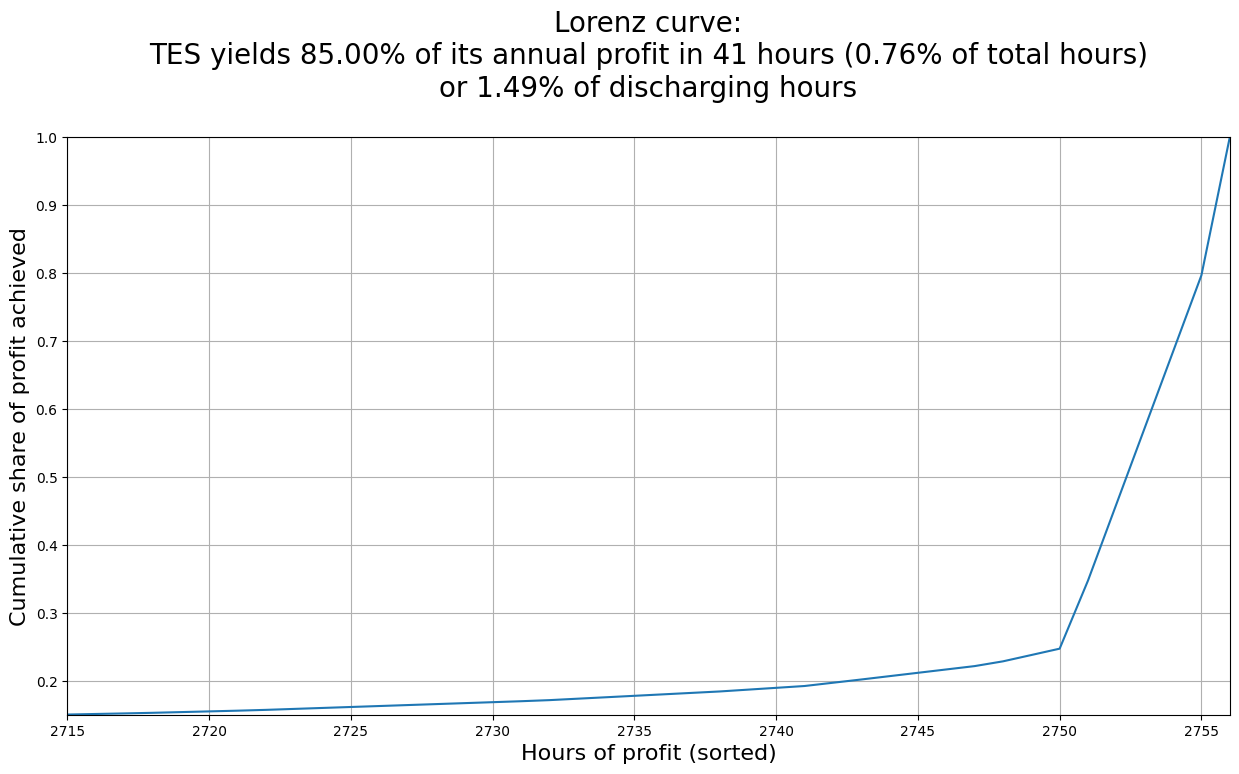

In [866]:
x_min = 8760
x_max = 0

cum_x_delta = 0

fig = plt.figure(figsize=(15,7.5))
ax1 = plt.subplot(111)

for y in year_list:
    sort_profit_y = dict_sort_profits[y]['Sorted profits']
    sort_cumprofit_y = dict_sort_profits[y]['Sorted cumulated profits']
    sort_cumprofit_rel_y = dict_sort_profits[y]['Sorted relative cumulated profits']

    x_min_y = sort_cumprofit_rel_y.index[sort_cumprofit_rel_y >= y_min].tolist()[0]
    x_max_y = min(sort_cumprofit_rel_y.index[sort_cumprofit_rel_y >= y_max].tolist()[0], (dict_df_years[y]["TES profit"] > 0).sum())

    cum_x_delta += x_max_y - x_min_y

    # print(f"{y} : {x_min_y} and {x_max_y}")

    if x_min_y < x_min:
        x_min = x_min_y
    # end if

    if x_max_y > x_max:
        x_max = x_max_y
    # end if

    ax1.plot(sort_cumprofit_rel_y)
# end for

title_line2_1 = f"TES yields {1-y_min:>6.2%} of its annual profit in "
title_line2_2 = f"{cum_x_delta/nb_years:,.0f} hours "
title_line2_3 = f"({cum_x_delta/(hours_discharging+hours_charging):.2%} of total hours)"
title_line3 = f"or {cum_x_delta/hours_discharging:.2%} of discharging hours"

ax1.set_title(
    f'Lorenz curve:\n'
    f'{title_line2_1}{title_line2_2}{title_line2_3}\n'
    f'{title_line3}\n'
, fontsize=20)

ax1.set_ylim((y_min, y_max))
ax1.set_xlim((x_min, x_max))
ax1.set_xlabel('Hours of profit (sorted)', fontsize=16)
ax1.set_ylabel('Cumulative share of profit achieved', fontsize=16)
ax1.grid(which='both')

## Incremental 1 MW TES "iTES" external optimisation

### iTES instantiation

In [899]:
iTES_capacity_MW_th = 1
iTES_duration = TES_min_discharge_duration_on#45.49 #8.69#45.1#
iTES_capacity_MWh_th = iTES_capacity_MW_th * iTES_duration

TES_FPP_option = "FPP_TES" # "FPP_TES", "FPP_TES_free", or "Indep_TES"
FPP_minlevel = .525

In [900]:
iTES_capacity_MWh_e = iTES_capacity_MWh_th * FPP_BOP_efficiency
iTES_capacity_MW_e = iTES_capacity_MW_th * FPP_BOP_efficiency

icapacity_energy = {"TES" : iTES_capacity_MWh_e}

iTES_min_charge_duration = iTES_capacity_MWh_e / iTES_capacity_MW_e
iTES_max_turnover = 8760 / (2 * iTES_min_charge_duration)

iTES_cost = iTES_capacity_MWh_e * CAPEX_MWh_e + iTES_capacity_MW_e * (CAPEX_MW_e_BoP + CAPEX_MW_e_TES)
iTES_cost_lb = 662.17810119575 * 1000 * iTES_capacity_MW_e
iTES_cost_avg = 1731.29453003352 * 1000 * iTES_capacity_MW_e
iTES_cost_ub = 2915.52651416685 * 1000 * iTES_capacity_MW_e

Annualized_iTES_cost = (Discount_rate * iTES_cost) / (1 - (1 + Discount_rate)**(-TES_lifetime))
Annualized_iTES_cost_lb = (Discount_rate * iTES_cost_lb) / (1 - (1 + Discount_rate)**(-TES_lifetime))
Annualized_iTES_cost_avg = (Discount_rate * iTES_cost_avg) / (1 - (1 + Discount_rate)**(-TES_lifetime))
Annualized_iTES_cost_ub = (Discount_rate * iTES_cost_ub) / (1 - (1 + Discount_rate)**(-TES_lifetime))

### Dispatch optimisation

#### Has this simulation already been done before?

In [901]:
if not os.path.exists(f"{directory}{scenario_selected}/Results/{sub_scenario_name}/Incremental_TES_Dispatch_{iTES_duration}"):
    scenario_to_be_optimized = True
    os.makedirs(f"{directory}{scenario_selected}/Results/{sub_scenario_name}/Incremental_TES_Dispatch_{iTES_duration}")
elif len(os.listdir(f"{directory}{scenario_selected}/Results/{sub_scenario_name}/Incremental_TES_Dispatch_{iTES_duration}")) < nb_years:
    scenario_to_be_optimized = True
else:
    scenario_to_be_optimized = False
# end if
# scenario_to_be_optimized = True

#### Model and solver instanciation

In [902]:
if scenario_to_be_optimized:
    # Create the linear solver with the GLOP backend.
    solver = pywraplp.Solver.CreateSolver("GLOP")
    if not solver:
        print("Could not create solver GLOP")
    # end if
# end if

In [903]:
if scenario_to_be_optimized:
    # Create the variables powerflow (convention: powerflow > 0 indicates that TES is charging) and soc
    discharging_vars = [solver.NumVar(-iTES_capacity_MW_th, 0, f"discharging_{i}") for i in range(nb_years * 8760)]
    charging_vars = [solver.NumVar(0, iTES_capacity_MW_th, f"charging_{i}") for i in range(nb_years * 8760)]

    soc_vars = [solver.NumVar(0, iTES_capacity_MWh_th, f"soc_{i}") for i in range(nb_years * 8760)]

    print("Number of variables =", solver.NumVariables())
# end if

Number of variables = 26280


In [904]:
if scenario_to_be_optimized:
    infinity = solver.infinity()

    constraint_soc_dict = {}
    constraint_FPP_dict_min = {}
    constraint_FPP_dict_max = {}
    constraint_FPP_dict_discharge = {}

    price_df = pd.concat([dict_df_years[y]["Price z2"] for y in year_list], ignore_index=True)
    if not TES_FPP_option == "Indep_TES":
        fusion_df = pd.concat([dict_df_years[y]["Reactor output MWht"] for y in year_list], ignore_index=True)
    # end if

    # Create the linear constraints on the SoC

    for i in range(nb_years * 8760):

        # All constraints are equality constraints, the boundaries are set in the definition of the variable
        constraint_soc_dict.update({i : solver.Constraint(0, 0, "ct")})
        if i%8760 == 0:
            # First timestep of a year: soc[0] = 0
            constraint_soc_dict[i].SetCoefficient(soc_vars[i], 1)
            # constraint_soc_dict[i].SetCoefficient(soc_vars[i+8759], -(1 - TES_hourly_leakage_rate))
            # constraint_soc_dict[i].SetCoefficient(charging_vars[i+8759], -TES_efficiency_ratio_charge)
            # constraint_soc_dict[i].SetCoefficient(discharging_vars[i+8759], -(1/TES_efficiency_ratio_discharge))
        else:
            # Generic timestep of a year: soc[t] - (1-TES_hourly_leakage_rate) * soc[t-1] - TES_efficiency_ratio_charge * charging_vars[t-1] - (1/TES_efficiency_ratio_discharge) * discharging_vars[t-1] = 0
            constraint_soc_dict[i].SetCoefficient(soc_vars[i], 1)
            constraint_soc_dict[i].SetCoefficient(soc_vars[i-1], -(1 - TES_hourly_leakage_rate))
            constraint_soc_dict[i].SetCoefficient(charging_vars[i-1], -TES_eff_ratio_charge)
            constraint_soc_dict[i].SetCoefficient(discharging_vars[i-1], -(1/TES_eff_ratio_discharge))
        # end if

        if TES_FPP_option[:7] == "FPP_TES":
            # If this option is enabled, we limit:
            # >>> the charge of TES to time steps where FPP is above the FPP_minlevel value and below the FPP nameplate capacity
            # >>> the discharge of TES to time steps where FPP at nameplate capacity
            if fusion_df[i] < FPP_minlevel * FPP_total_capacity:
                # The TES_charge[i] = 0 constraint is created iff the FPP[i] is below the thershold
                constraint_FPP_dict_min.update({i : solver.Constraint(0, 0, "ct")})
                constraint_FPP_dict_min[i].SetCoefficient(charging_vars[i], 1)
            # end if

            if FPP_total_capacity - fusion_df[i] < 1:
                # The TES_charge[i] = 0 constraint is created iff the FPP[i] is below the thershold
                constraint_FPP_dict_max.update({i : solver.Constraint(0, 0, "ct")})
                constraint_FPP_dict_max[i].SetCoefficient(charging_vars[i], 1)
            # end if

            if fusion_df[i] < FPP_total_capacity:
                # The TES_discharge[i] = 0 constraint is created iff the FPP[i] is below nameplate capacity
                constraint_FPP_dict_discharge.update({i : solver.Constraint(0, 0, "ct")})
                constraint_FPP_dict_discharge[i].SetCoefficient(discharging_vars[i], 1)
            # end if
        # end if
    # end for

    print("Number of constraints =", solver.NumConstraints())
# end if

Number of constraints = 20796


#### Objective function

In [905]:
if scenario_to_be_optimized:
    # Create the objective function, sum(powerflow[i] * price[i]).

    objective = solver.Objective()
    for i in range(nb_years * 8760):
        objective.SetCoefficient(charging_vars[i], FPP_BOP_efficiency * price_df[i])
        objective.SetCoefficient(discharging_vars[i], FPP_BOP_efficiency * price_df[i])
    objective.SetMinimization()

    print(f"The objective function is the sum of the revenue from MWh_e sold to the grid (at a given price), minus the equivalent loss from charging the MWh_e instead of selling them")
# end if

The objective function is the sum of the revenue from MWh_e sold to the grid (at a given price), minus the equivalent loss from charging the MWh_e instead of selling them


In [906]:
if scenario_to_be_optimized:
    # options = pywraplp.ModelExportOptions()
    # model_as_string = solver.ExportModelAsLpFormat(True)
    pass
# end if

In [907]:
if scenario_to_be_optimized:
    # print(model_as_string)
    pass
# end if

#### Optimal resolution

In [908]:
if scenario_to_be_optimized:
    print(f"Solving with {solver.SolverVersion()}")
    result_status = solver.Solve()
    print(f"Status: {result_status}")
    if result_status != pywraplp.Solver.OPTIMAL:
        print("The problem does not have an optimal solution!")
        if result_status == pywraplp.Solver.FEASIBLE:
            print("A potentially suboptimal solution was found")
        else:
            print("The solver could not solve the problem.")
# end if

Solving with Glop solver v9.14.6206
Status: 0


In [909]:
if scenario_to_be_optimized:
    if objective.Value() < 0:
        print("A profitable solution has been found:")
        print(f"Cumulated operational profits = ${-objective.Value():,.2f}")
    else:
        print("No profitable solution has been found:")
        print(f"Total loss = ${-objective.Value():,.2f}")
# end if

A profitable solution has been found:
Cumulated operational profits = $960,698.06


#### Optimization results analysis

In [910]:
if scenario_to_be_optimized:
    dict_df_solution_export = {}

    powerflow_solutions = []
    charging_solutions = []
    discharging_solutions = []
    soc_solutions = []
    cashflow = []
    cum_cashflow = []

    powerflow_vars = [(charging_vars[i]+discharging_vars[i]) for i in range(nb_years * 8760)]

    for i in range(len(powerflow_vars)):
        powerflow_solutions.append(powerflow_vars[i].solution_value())
        charging_solutions.append(charging_vars[i].solution_value())
        discharging_solutions.append(discharging_vars[i].solution_value())
        soc_solutions.append(soc_vars[i].solution_value())
        cashflow.append(powerflow_vars[i].solution_value() * FPP_BOP_efficiency * -price_df[i])

    for y in range(1,len(year_list)+1):
        y_df = pd.DataFrame({f"SoC" : soc_solutions[8760*(y-1):8760*y], f"Powerflow (MW_th)" : powerflow_solutions[8760*(y-1):8760*y], f"Price ($/MWh_e)" : price_df[8760*(y-1):8760*y], f"Cashflow" : cashflow[8760*(y-1):8760*y]}).reset_index()
        
        y_df = pd.concat([y_df, y_df["Cashflow"].cumsum().rename("Cumulative cashflow")], axis=1)
        
        dict_df_solution_export.update({year_list[y-1]:y_df})
    # end for
# end if

#### Incremental TES dispatch import/export

In [923]:
if scenario_to_be_optimized:
    i = 0

    for y in range(1,len(year_list)+1):
        j = (i + 1)/nb_years
        
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  Dispatch exported to csv for year {year_list[y-1]}!" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        df_to_store_y = dict_df_solution_export[year_list[y-1]]

        df_to_store_y.to_csv(path_or_buf=f"{directory}{scenario_selected}/results/{sub_scenario_name}/Incremental_TES_Dispatch_{iTES_duration}/year_{year_list[y-1]}.csv")

        i += 1
    #end for
    dict_df_solution_import = dict_df_solution_export
    print("\nExporting and continuing")
else:
    dict_df_solution_import = {}
    for y in range(1,len(year_list)+1):
        dispatch_path = f"{directory}{scenario_selected}/results/{sub_scenario_name}/Incremental_TES_Dispatch_{iTES_duration}/year_{year_list[y-1]}.csv"
        df_y = pd.read_csv(dispatch_path, index_col=0)

        df_prices_y = df_y.loc[:,"Price ($/MWh_e)"]
        df_soc_y = df_y.loc[:,"SoC"]
        df_powerflow_y = df_y.loc[:,"Powerflow (MW_th)"].replace({np.nan : 0})
        df_cashflow_y = df_y.loc[:,"Cashflow"].replace({np.nan : 0})
        df_cumulated_cashflow_y = df_y.loc[:,"Cumulative cashflow"].replace({np.nan : 0})

        y_df = pd.DataFrame({f"SoC" : df_soc_y, f"Powerflow (MW_th)" : df_powerflow_y, f"Price ($/MWh_e)" : df_prices_y, f"Cashflow" : df_cashflow_y, f"Cumulative cashflow" : df_cumulated_cashflow_y})#.reset_index()

        dict_df_solution_import.update({year_list[y-1]:y_df})
    # end for
    print("\nImporting and continuing")
# end if

[====================] 100%  ---  Dispatch exported to csv for year 4!
Exporting and continuing


### iTES SoC profile

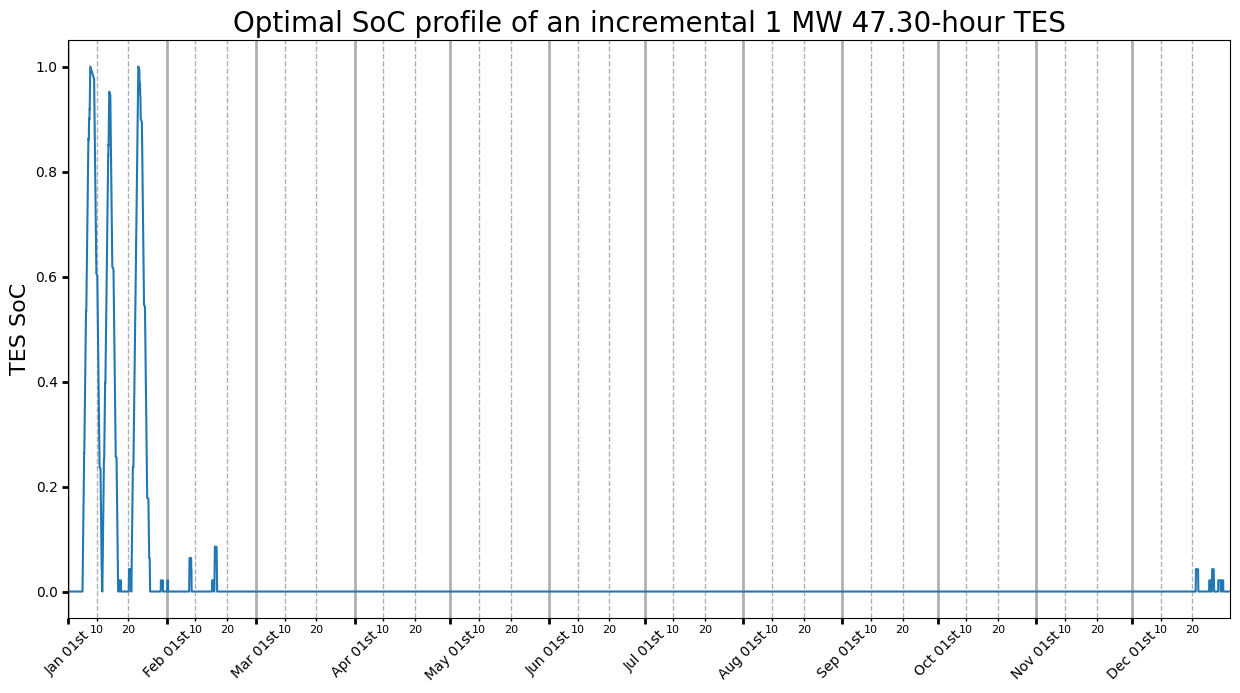

In [951]:
if TES_normalized_level_bool:
    fig = plt.figure(figsize=(15,7.5))
    ax1 = plt.subplot(111)

    start_tick = 0#480 #31*24
    end_tick = 8760#720 #31*24+28*24+1

    ref_date = pd.to_datetime('01/01/2050')

    start_date = ref_date + pd.DateOffset(hours=start_tick)
    end_date = ref_date + pd.DateOffset(hours=end_tick)

    x_data = pd.date_range(start=start_date, end=end_date, freq='h', inclusive='left')
    x_data_8760 = [(date - ref_date).total_seconds()/3600 for date in x_data]

    x_labels = [date.strftime('%b %d') for date in x_data]
    x_label_title = [x_data[i].strftime('%B %dth') for i in [0, -1]]

    for y in year_list:
        ax1.plot(x_data, dict_df_solution_import[y][f"SoC"][x_data_8760]/iTES_capacity_MWh_th)
        # (dict_df_years[y]["TES level MWht"].rename(f"Year {y} : {float(profit_storage_df.loc['TES annual discharge (full-cycles)', f'Year {y}']):.2e} cycles") / (TES_capacity_MWh_th)).plot(ax=ax1, title="TES normalized level", legend=True)
    # end for

# .rename(f"Year {y} : {float(TES_annual_turnover[f"Year {y}"]):.0f} cycles")

    ax1.set_xlim(x_data[0], x_data[-1])

    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %dst'))

    ax1.tick_params(which='major', width=2)
    ax1.tick_params(which='major', length=10)
    ax1.tick_params(which='major', axis='x', labelrotation=45)

    ax1.xaxis.set_minor_locator(mdates.DayLocator(bymonthday=[10,20]))
    ax1.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))
    ax1.tick_params(which='minor', width=1)
    ax1.tick_params(which='major', length=4)
    ax1.tick_params(which='minor', labelsize=8)

    ax1.grid(which='major', axis='x', linestyle='-', linewidth=2)
    ax1.grid(which='minor', axis='x', linestyle='--', linewidth=1)

    ax1.set_title(f"Optimal SoC profile of an incremental 1 MW {iTES_duration:,.2f}-hour TES", fontsize=20)
    ax1.set_ylabel("TES SoC", fontsize=16)
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

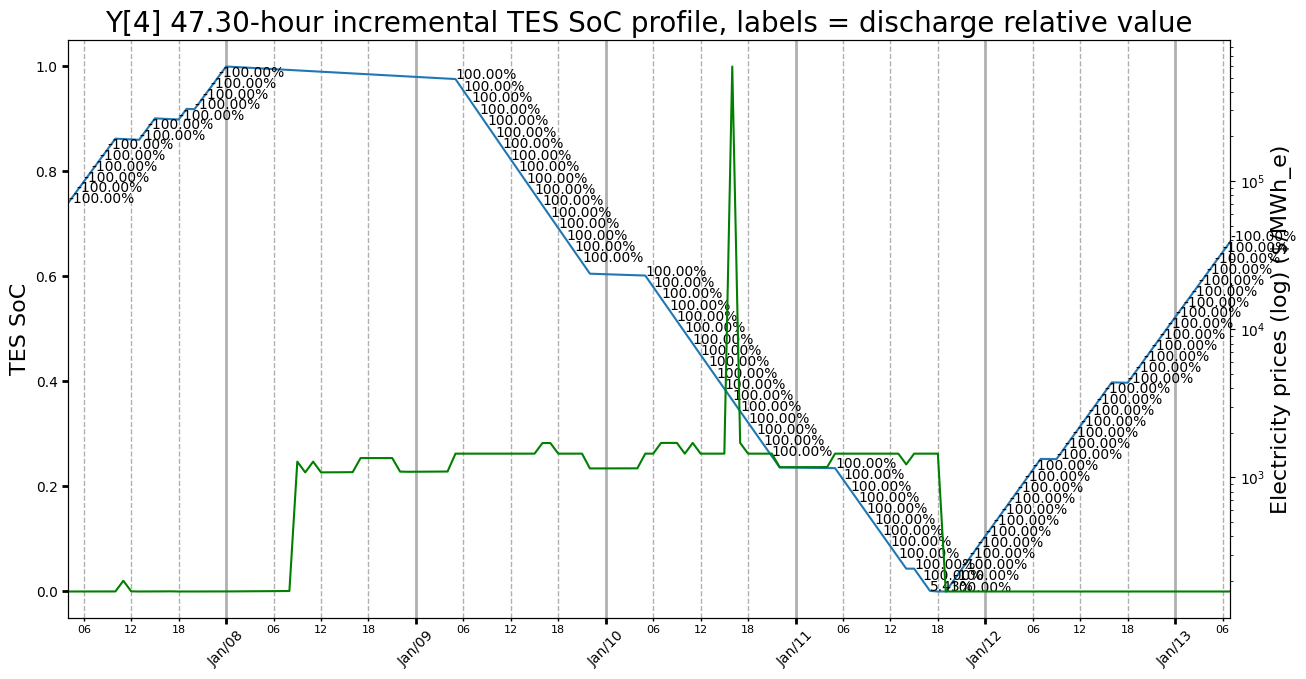

In [950]:
if TES_normalized_level_bool:

    LOCAL_YEAR_LIST = year_list[:1]
    LOCAL_X_START = 148
    LOCAL_X_END = LOCAL_X_START + 148

    fig = plt.figure(figsize=(15,7.5))
    ax1 = plt.subplot(111)
    # fig = plt.figure(figsize=(15,22.5))
    # ax1 = plt.subplot(311)
    # ax2 = plt.subplot(312)
    # ax3 = plt.subplot(313)

    ax_list = [ax1]#[ax1, ax2, ax3]
    ax_tech_dict = {ax1 : "TES"}
    ax_soc_dict = {ax1 : "SoC"}
    ax_capa_energy_dict = {ax1 : iTES_capacity_MWh_th}
    ax_capa_discharge_dict = {ax1 : iTES_capacity_MW_th}
    ax_netdisch_dict = {ax1 : "Powerflow (MW_th)"}

    label_threshold = .0

    start_tick = LOCAL_X_START
    end_tick = LOCAL_X_END

    ref_date = pd.to_datetime('01/01/2050')

    start_date = ref_date + pd.DateOffset(hours=start_tick)
    end_date = ref_date + pd.DateOffset(hours=end_tick)

    x_data = pd.date_range(start=start_date, end=end_date, freq='h', inclusive='left')
    x_data_8760 = [(date - ref_date).total_seconds()/3600 for date in x_data]

    x_labels = [date.strftime('%b %d') for date in x_data]
    x_label_title = [x_data[i].strftime('%B %dth') for i in [0, -1]]

    for y in LOCAL_YEAR_LIST:
        for ax in ax_list:
            ax.plot(x_data, dict_df_solution_import[y][ax_soc_dict[ax]][x_data_8760] / (ax_capa_energy_dict[ax]))

            for xy in zip(x_data, dict_df_solution_import[y][ax_soc_dict[ax]][x_data_8760] / (ax_capa_energy_dict[ax])):
                label_y = -dict_df_solution_import[y][ax_netdisch_dict[ax]][(xy[0]-ref_date).total_seconds()/3600] / (ax_capa_discharge_dict[ax])

                # No efficiency here because we consider the thermal flow and the thermal SoC
                # if label_y < 0:
                #     # Charging efficiency should be applied
                #     label_y /= eff_up_dict[ax_tech_dict[ax]]
                # elif label_y > 0:
                #     # Disharging efficiency should be applied
                #     label_y *= eff_down_dict[ax_tech_dict[ax]]
                # # end if

                if abs(label_y) > label_threshold:
                    ax.annotate(f'{label_y:.2%}', xy=xy, textcoords='data')
                # end if
            # end for xy

            axbis = ax.twinx()
            axbis.set_yscale('log')
            axbis.plot(x_data, dict_df_solution_import[y]["Price ($/MWh_e)"][x_data_8760], color='g')
            axbis.set_ylabel(f"Electricity prices (log) ($/MWh_e)", fontsize=16)
        # end for ax
    # end for y

    for ax in ax_list:
        ax.set_xlim(x_data[0], x_data[-1])

        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%d'))

        ax.tick_params(which='major', width=2)
        ax.tick_params(which='major', length=10)
        ax.tick_params(which='major', axis='x', labelrotation=45)

        ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
        ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H'))
        ax.tick_params(which='minor', width=1)
        ax.tick_params(which='major', length=4)
        ax.tick_params(which='minor', labelsize=8)

        ax.grid(which='major', axis='x', linestyle='-', linewidth=2)
        ax.grid(which='minor', axis='x', linestyle='--', linewidth=1)

        ax.set_title(f"Y{LOCAL_YEAR_LIST} {iTES_duration:,.2f}-hour incremental {ax_tech_dict[ax]} SoC profile, labels = discharge relative value", fontsize=20)
        ax.set_ylabel(f"{ax_tech_dict[ax]} SoC", fontsize=16)
    # end for ax
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

### iTES performance

In [934]:
profit_storage = {}

for y in year_list:
    profit_storage_y = {}
    for tech in ["TES"]:
        if tech != "TES":
            discharged_energy_y_tech = (dict_df_solution_import[y][f"Powerflow (MW_e)"] * (dict_df_solution_import[y][f"Powerflow (MW_e)"] < 0)).sum()
        else:
            discharged_energy_y_tech = -(dict_df_solution_import[y][f"Powerflow (MW_th)"] * (dict_df_solution_import[y][f"Powerflow (MW_th)"] < 0) * FPP_BOP_efficiency).sum()
        #end if

        profit_storage_y.update({f"{tech} operational profit ($)" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759]),
                                    f"{tech} net operational profit lb ($)" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost_lb),
                                    f"{tech} net operational profit avg($)" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost_avg),
                                    f"{tech} net operational profit ($)" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost),
                                    f"{tech} net operational profit ub ($)" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost_ub),
                                    f"{tech} net margin lb" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost_lb)/Annualized_iTES_cost_lb, 
                                    f"{tech} net margin avg" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost_avg)/Annualized_iTES_cost_avg, 
                                    f"{tech} net margin" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost)/Annualized_iTES_cost,
                                    f"{tech} net margin ub" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759] - Annualized_iTES_cost_ub)/Annualized_iTES_cost_ub, 
                                    f"{tech} annual discharge (MWh_e)" : float(discharged_energy_y_tech),
                                    f"{tech} annual discharge (full-cycles)" : float(discharged_energy_y_tech)/icapacity_energy[tech],
                                    f"{tech} average turnover profit ($/MWh_e)" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759])/float(discharged_energy_y_tech),
                                    f"{tech} average turnover profit ($ per full-cycle)" : float(dict_df_solution_import[y][f"Cumulative cashflow"][8759])/float(discharged_energy_y_tech)*icapacity_energy[tech],
                                    f"{tech} mean charging prices ($/MWh_e)" : dict_df_solution_import[y][f"Price ($/MWh_e)"].where(dict_df_solution_import[y][f"Powerflow (MW_th)"] > 0).mean(),
                                    f"{tech} mean discharging prices ($/MWh_e)" : dict_df_solution_import[y][f"Price ($/MWh_e)"].where(dict_df_solution_import[y][f"Powerflow (MW_th)"] < 0).mean()
                                    })
    # end for
    profit_storage.update({f"Year {y}":profit_storage_y})
# end for

profit_storage_df = pd.DataFrame(data=profit_storage)
pd.options.display.float_format = '{:,.2f}'.format

# print(profit_storage_df)

In [935]:
mean_turnover_count = profit_storage_df.loc["TES annual discharge (full-cycles)", profit_storage_df.columns[0]:profit_storage_df.columns[-1]].mean()
mean_turnover_profit = profit_storage_df.loc["TES average turnover profit ($ per full-cycle)", profit_storage_df.columns[0]:profit_storage_df.columns[-1]].mean()
mean_MWhe_profit = mean_turnover_profit/iTES_capacity_MWh_e

cumulated_profit = profit_storage_df.loc["TES operational profit ($)", profit_storage_df.columns[0]:profit_storage_df.columns[-1]].sum()

target_turnover_profit = Annualized_iTES_cost/mean_turnover_count
target_MWhe_profit = target_turnover_profit/iTES_capacity_MWh_e

print(f"The TES cycles {mean_turnover_count:,.1f} times per year (in average). It equals to {mean_turnover_count*TES_lifetime:,.0f} turnovers during its {TES_lifetime}-year lifetime.")
print(f"Annualizing the capital costs on {TES_lifetime} years, the TES should capture at least ${target_turnover_profit:,.2f}/turnover.")
print(f"Equivalently, it should capture ${target_MWhe_profit:,.2f}/MWh_e discharged.")
print("-----------")
print(f"The optimized TES", "reaches" if mean_turnover_profit > target_turnover_profit else "misses", "this target")
print(f"The TES captures an average ${mean_turnover_profit:,.2f}/turnover ({mean_turnover_profit - target_turnover_profit:+,.2f} compared to target).")
print(f"Equivalently, it captures ${mean_MWhe_profit:,.2f}/MWh_e discharged ({mean_MWhe_profit-target_MWhe_profit:+,.2f} compared to target)")
print("-----------")
print(f"TES average net profitability: ${profit_storage_df.loc['TES net operational profit ($)', profit_storage_df.columns[0]:profit_storage_df.columns[-1]].mean():+,.2f}/year, equivalent to {profit_storage_df.loc['TES net margin', profit_storage_df.columns[0]:profit_storage_df.columns[-1]].mean():+.2%} of capital costs")
print("-----------")
print(f'TES mean charging price: ${profit_storage_df.loc["TES mean charging prices ($/MWh_e)", profit_storage_df.columns[0]:profit_storage_df.columns[-1]].mean():,.2f}/MWh_e')
print(f'TES mean discharging price: ${profit_storage_df.loc["TES mean discharging prices ($/MWh_e)", profit_storage_df.columns[0]:profit_storage_df.columns[-1]].mean():,.2f}/MWh_e')

The TES cycles 3.3 times per year (in average). It equals to 130 turnovers during its 40-year lifetime.
Annualizing the capital costs on 40 years, the TES should capture at least $30,809.99/turnover.
Equivalently, it should capture $1,628.51/MWh_e discharged.
-----------
The optimized TES reaches this target
The TES captures an average $295,063.39/turnover (+264,253.40 compared to target).
Equivalently, it captures $15,596.05/MWh_e discharged (+13,967.54 compared to target)
-----------
TES average net profitability: $+860,383.68/year, equivalent to +857.69% of capital costs
-----------
TES mean charging price: $169.67/MWh_e
TES mean discharging price: $15,591.72/MWh_e


## Profitability thresholds

In [936]:
non_optimized_years_on_plot = True

if non_optimized_years_on_plot:
    yearly_TES_turnovers_non_optimized = profit_storage_tech_y_df["TES"].transpose()["Annual discharge (full-cycles)"].values
    yearly_TES_profit_per_MWh_e_discharged_non_optimized = profit_storage_tech_y_df["TES"].transpose()["Average turnover profit ($/MWh_e)"].values
    yearly_TES_profit_per_turnover_non_optimized = profit_storage_tech_y_df["TES"].transpose()["Average turnover profit ($ per full-cycle)"].values
    label_data_non_optimized = []

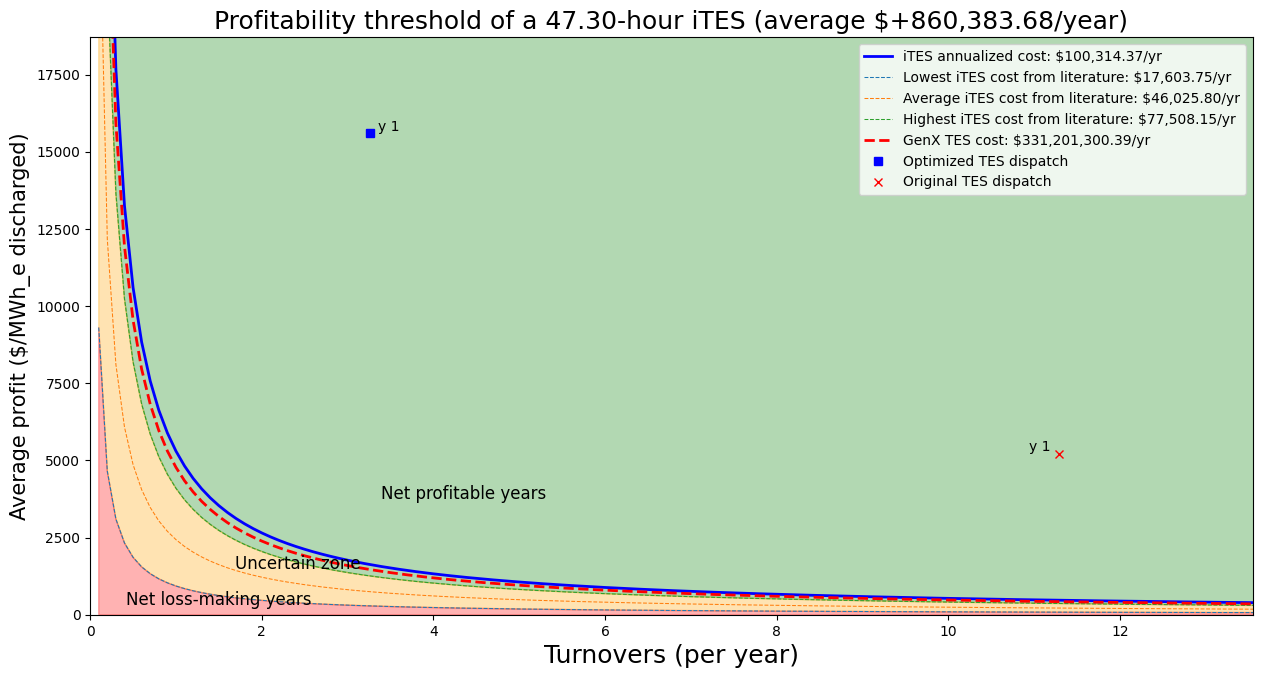

In [937]:
if True:
    fig = plt.figure(figsize=(15,7.5))
    ax1 = plt.subplot(111)

    if not non_optimized_years_on_plot:
        ax2 = ax1.twinx()
    # end if

    if non_optimized_years_on_plot:
        x_ub = 1.2 * max(
                        yearly_TES_turnovers_non_optimized.max(),
                        profit_storage_df.loc["TES annual discharge (full-cycles)"].max()
                        )
        y_ub = 1.2 * max(
                        yearly_TES_profit_per_MWh_e_discharged_non_optimized.max(),
                        Annualized_TES_cost / (yearly_TES_turnovers_non_optimized.max() * TES_capacity_MWh_e),
                        profit_storage_df.loc["TES average turnover profit ($/MWh_e)", profit_storage_df.columns[0]:profit_storage_df.columns[-1]].max(),
                        Annualized_iTES_cost / (profit_storage_df.loc["TES annual discharge (full-cycles)"].max() * iTES_capacity_MWh_e)
                        )
    else:
        x_ub = 1.2 * profit_storage_df.loc["TES annual discharge (full-cycles)"].max()
        y_ub = 1.2 * max(
                        profit_storage_df.loc["TES average turnover profit ($/MWh_e)", profit_storage_df.columns[0]:profit_storage_df.columns[-1]].max(),
                        Annualized_iTES_cost / (profit_storage_df.loc["TES annual discharge (full-cycles)"].max() * iTES_capacity_MWh_e)
                        )
    # end if

    # We only plot the abscisses from 0 cycles to the maximum possible (according to the minimal charging/discharging time)
    x = np.linspace(0.1,(int(TES_max_turnover_off)+1), 10*(int(TES_max_turnover_off)+1))
    y_1 = []
    y_1_lb, y_1_avg, y_1_ub = [], [], []
    y_2_avg = []

    line_list = []
    line_label_list = []

    if non_optimized_years_on_plot:
        y_1_non_optimized = []
    # end if

    for turnover in x:
        y_1.append(Annualized_iTES_cost / (turnover * iTES_capacity_MWh_e))
        
        y_1_lb.append(Annualized_iTES_cost_lb / (turnover * iTES_capacity_MWh_e))
        y_1_avg.append(Annualized_iTES_cost_avg / (turnover * iTES_capacity_MWh_e))
        y_1_ub.append(Annualized_iTES_cost_ub / (turnover * iTES_capacity_MWh_e))

        y_2_avg.append(Annualized_iTES_cost_avg / (turnover))

        if non_optimized_years_on_plot:
            y_1_non_optimized.append(Annualized_TES_cost / (turnover * TES_capacity_MWh_e))
        # end if
    # end for

    FF_line, = ax1.plot(x, y_1, lw=2, ls="-", color='b')
    line_list.append(FF_line)
    line_label_list.append(f"iTES annualized cost: ${Annualized_iTES_cost:,.2f}/yr")

    if nb_years > 1:
        optimized_barycenter, = ax1.plot(mean_turnover_count, mean_MWhe_profit, "bD", markersize=10)
    # end if

    lb_line, = ax1.plot(x, y_1_lb, lw=.75, ls="--")
    line_list.append(lb_line)
    line_label_list.append(f"Lowest iTES cost from literature: ${Annualized_iTES_cost_lb:,.2f}/yr")

    avg_line, = ax1.plot(x, y_1_avg, lw=.75, ls="--")
    line_list.append(avg_line)
    line_label_list.append(f"Average iTES cost from literature: ${Annualized_iTES_cost_avg:,.2f}/yr")

    ub_line, = ax1.plot(x, y_1_ub, lw=.75, ls="--")
    line_list.append(ub_line)
    line_label_list.append(f"Highest iTES cost from literature: ${Annualized_iTES_cost_ub:,.2f}/yr")

    if non_optimized_years_on_plot:
        # non_optimized_line, = ax1.plot(x, y_1_non_optimized, lw=2, ls="dashed")
        # line_list.append(non_optimized_line)
        # line_label_list.append(f"Annualized cost of original TES: ${Annualized_TES_cost:,.2f}/yr")

        non_optimized_line2, = ax1.plot(x, y_1_non_optimized, lw=2, ls="dashed", color='r')
        line_list.append(non_optimized_line2)
        line_label_list.append(f"GenX TES cost: ${Annualized_TES_cost:,.2f}/yr")

        if nb_years > 1:
            non_optimized_barycenter, = ax1.plot(TES_mean_turnover_count, TES_mean_spread, 'rP', markersize=10)
        # end if
    # end ir

    ax1.set_title(f"Profitability threshold of a {iTES_duration:.2f}-hour iTES (average ${profit_storage_df.loc['TES net operational profit ($)', profit_storage_df.columns[0]:profit_storage_df.columns[-1]].mean():+,.2f}/year)", fontsize=18)
    ax1.set_xlabel("Turnovers (per year)", fontsize=18)
    ax1.set_ylabel("Average profit ($/MWh_e discharged)", fontsize=15)
    ax1.set_xlim(0,x_ub)
    ax1.set_ylim(0,y_ub)
    
    if not non_optimized_years_on_plot:
        ax2.plot(x, y_2_avg, lw=.05, ls="--")
        ax2.set_ylabel("Average profit ($/turnover)", fontsize=15)
        ax2.set_ylim(0,y_ub * iTES_capacity_MWh_e)
    # end if
    

    yearly_iTES_turnovers = []
    yearly_iTES_profit_per_MWh_e_discharged = []
    yearly_iTES_profit_per_turnover = []

    for y in year_list:
        yearly_iTES_turnovers.append(float(profit_storage_df.loc["TES annual discharge (full-cycles)", f"Year {y}"]))
        yearly_iTES_profit_per_MWh_e_discharged.append(float(profit_storage_df.loc["TES average turnover profit ($/MWh_e)", f"Year {y}"]))
        yearly_iTES_profit_per_turnover.append(float(profit_storage_df.loc["TES average turnover profit ($ per full-cycle)", f"Year {y}"]))
    # end for

    yearly_iTES_turnovers = np.array(yearly_iTES_turnovers)
    yearly_iTES_profit_per_MWh_e_discharged = np.array(yearly_iTES_profit_per_MWh_e_discharged)
    yearly_iTES_profit_per_turnover = np.array(yearly_iTES_profit_per_turnover)

    label_data = []

    # Associate labels to years above profitability threshold (criterium to be checked)
    for index in range(len(yearly_iTES_turnovers)):
        # if yearly_TES_profit_per_turnover_non_optimized[index] >= Annualized_TES_cost/(yearly_TES_turnovers_non_optimized[index]):
        #     label_data_non_optimized.append(f"y {index}")
        # else:
        #     label_data_non_optimized.append(f"")
        # # end if

        if yearly_iTES_profit_per_turnover[index] >= Annualized_iTES_cost/(yearly_iTES_turnovers[index]):
            label_data.append(f"y {index+1}")
            label_data_non_optimized.append(f"y {index+1}")
        else:
            label_data.append(f"")
            label_data_non_optimized.append(f"")
        # end if
    # end for

    # print(yearly_TES_turnovers)
    # print(yearly_TES_profit_per_MWh_e_discharged)

    optimzed_dispatch, = ax1.plot(yearly_iTES_turnovers, yearly_iTES_profit_per_MWh_e_discharged, "bs")
    line_list.append(optimzed_dispatch)
    line_label_list.append(f"Optimized TES dispatch")

    if non_optimized_years_on_plot:
        original_dispatch, = ax1.plot(yearly_TES_turnovers_non_optimized, yearly_TES_profit_per_MWh_e_discharged_non_optimized, "rx")
        line_list.append(original_dispatch)
        line_label_list.append(f"Original TES dispatch")

    # end if

    ax1.fill_between(x, y_1_ub, ax1.get_ylim()[-1], where=[True for elt in x], color="green", alpha=.3)
    ax1.fill_between(x, y_1_lb, y_1_ub, where=[True for elt in x], color="orange", alpha=.3)
    ax1.fill_between(x, ax1.get_ylim()[0], y_1_lb, where=[True for elt in x], color="red", alpha=.3)

    ax1.text(1/4 * ax1.get_xlim()[-1], 1/5 * ax1.get_ylim()[-1], f"Net profitable years", fontsize=12)
    ax1.text(1/8 * ax1.get_xlim()[-1], 1/12.5 * ax1.get_ylim()[-1], f"Uncertain zone", fontsize=12)
    ax1.text(1/32 * ax1.get_xlim()[-1], 1/60 * ax1.get_ylim()[-1], f"Net loss-making years", fontsize=12)


    for index in range(len(yearly_iTES_turnovers)):
        if label_data[index] != "":
            ax1.annotate(label_data[index], # this is the text
                 (yearly_iTES_turnovers[index],yearly_iTES_profit_per_MWh_e_discharged[index]), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(6,2), # distance from text to points (x,y)
                 ha='left') # horizontal alignment can be left, right or center
        # end if
        if non_optimized_years_on_plot:    
            if label_data_non_optimized[index] != "":
                ax1.annotate(label_data_non_optimized[index], # this is the text
                     (yearly_TES_turnovers_non_optimized[index],yearly_TES_profit_per_MWh_e_discharged_non_optimized[index]), # these are the coordinates to position the label
                     textcoords="offset points", # how to position the text
                     xytext=(-6,2), # distance from text to points (x,y)
                     ha='right') # horizontal alignment can be left, right or center
            # end if
        # end if
    # end for

    if nb_years > 1:
        ax1.annotate('iTES', (mean_turnover_count, mean_MWhe_profit), textcoords="offset fontsize", xytext=(-.75,0), ha='right', va='center', size=20, color='b')
        ax1.annotate('TES', (TES_mean_turnover_count, TES_mean_spread), textcoords="offset fontsize", xytext=(-.75,0), ha='right', va='center', size=20, color='r')
    # end if

    plt.legend(line_list, line_label_list)

else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

## TES/price and TES/FPP plots

### GenX TES operations

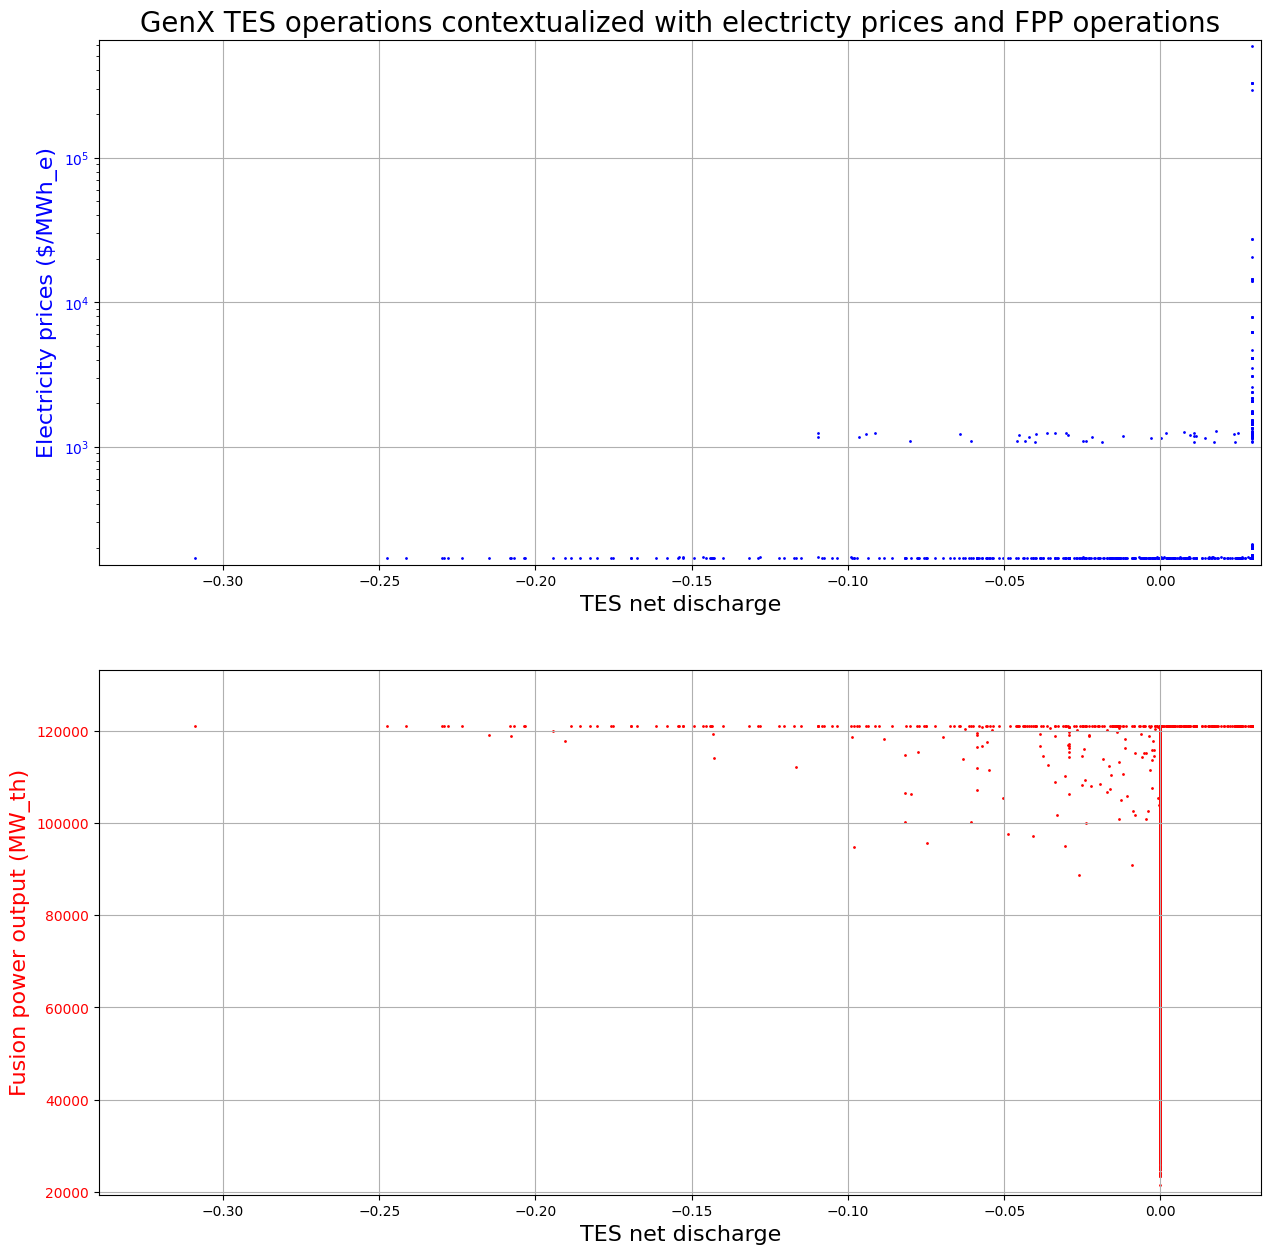

In [938]:
if True:
    fig = plt.figure(figsize=(15,15))
    ax1 = plt.subplot(211)
    ax2 = plt.subplot(212)

    net_discharge_df = pd.concat([dict_df_years[y]["TES net discharge MWht"] for y in year_list], axis = 0, ignore_index=True)/TES_dis_capacity_MW_th
    price_df = pd.concat([dict_df_years[y]["Price z2"] for y in year_list], axis = 0, ignore_index=True)
    fusion_df = pd.concat([dict_df_years[y]["Reactor output MWht"] for y in year_list], axis = 0, ignore_index=True)

    # Common x_axis = TES net discharge ratio
    x_lb = 1.1 * net_discharge_df.min()
    x_ub = 1.1 * net_discharge_df.max()

    # Upper y axis = electricity prices
    y1_lb = 0.9*price_df.min()
    y1_ub = 1.1*price_df.max()

    # Lower y axis = fusion power output
    y2_lb = 0.9*fusion_df.min()
    y2_ub = 1.1*fusion_df.max()

    ax1.scatter(net_discharge_df, price_df, s=1, c='b', label='Electricity prices ($/MWh_e)')
    ax1.set_xlabel("TES net discharge", fontsize=16)
    ax1.set_ylabel("Electricity prices ($/MWh_e)", fontsize=16, color='b')
    ax1.set_xlim(x_lb, x_ub)
    ax1.set_ylim(y1_lb, y1_ub)
    ax1.set_yscale('log')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True)

    ax2.scatter(net_discharge_df, fusion_df, s=1, c='r', label='Fusion power output (MW_th)')
    ax2.set_xlabel("TES net discharge", fontsize=16)
    ax2.set_ylabel("Fusion power output (MW_th)", fontsize=16, color='r')
    ax2.set_xlim(x_lb, x_ub)
    ax2.set_ylim(y2_lb, y2_ub)
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.grid(True)

    ax1.set_title('GenX TES operations contextualized with electricty prices and FPP operations', fontsize=20)

else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

### iTES operations

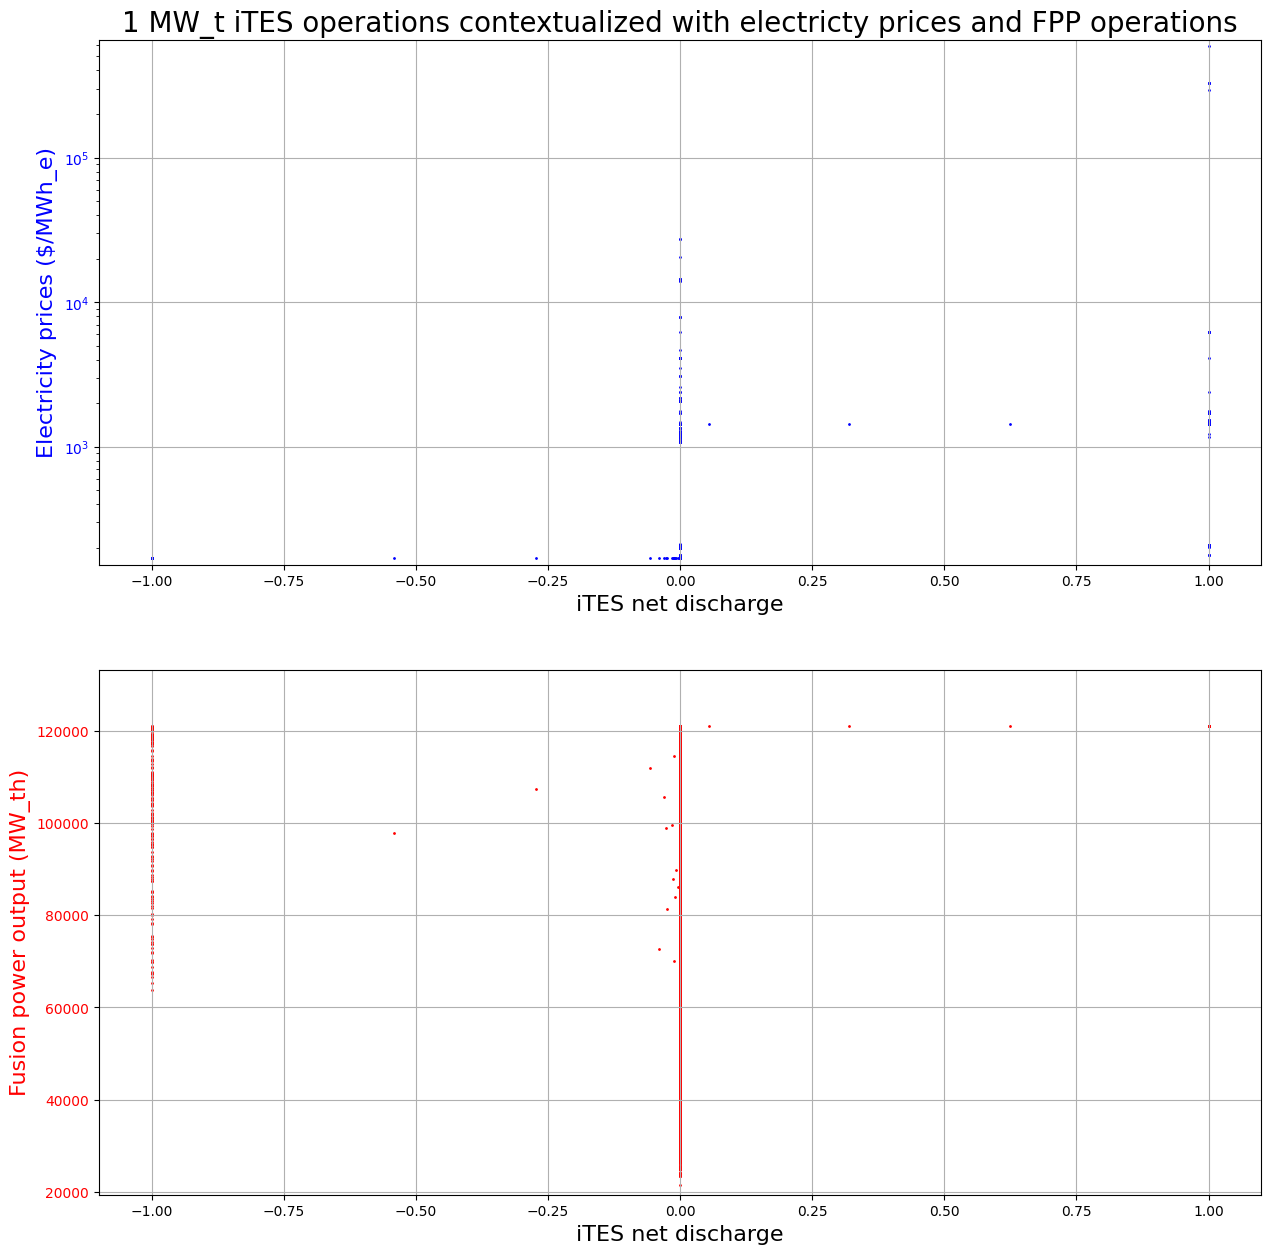

In [939]:
if True:
    fig = plt.figure(figsize=(15,15))
    ax1 = plt.subplot(211)
    ax2 = plt.subplot(212)

    net_discharge_df = -pd.concat([dict_df_solution_import[y]["Powerflow (MW_th)"] for y in year_list], axis = 0, ignore_index=True)/iTES_capacity_MW_th
    price_df = pd.concat([dict_df_years[y]["Price z2"] for y in year_list], axis = 0, ignore_index=True)
    fusion_df = pd.concat([dict_df_years[y]["Reactor output MWht"] for y in year_list], axis = 0, ignore_index=True)

    # Common x_axis = TES net discharge ratio
    x_lb = 1.1 * net_discharge_df.min()
    x_ub = 1.1 * net_discharge_df.max()

    # Upper y axis = electricity prices
    y1_lb = 0.9*price_df.min()
    y1_ub = 1.1*price_df.max()

    # Lower y axis = fusion power output
    y2_lb = 0.9*fusion_df.min()
    y2_ub = 1.1*fusion_df.max()

    ax1.scatter(net_discharge_df, price_df, s=1, c='b', label='Electricity prices ($/MWh_e)')
    ax1.set_xlabel("iTES net discharge", fontsize=16)
    ax1.set_ylabel("Electricity prices ($/MWh_e)", fontsize=16, color='b')
    ax1.set_xlim(x_lb, x_ub)
    ax1.set_ylim(y1_lb, y1_ub)
    ax1.set_yscale('log')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True)

    ax2.scatter(net_discharge_df, fusion_df, s=1, c='r', label='Fusion power output (MW_th)')
    ax2.set_xlabel("iTES net discharge", fontsize=16)
    ax2.set_ylabel("Fusion power output (MW_th)", fontsize=16, color='r')
    ax2.set_xlim(x_lb, x_ub)
    ax2.set_ylim(y2_lb, y2_ub)
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.grid(True)

    ax1.set_title(f'{iTES_capacity_MW_th} MW_t iTES operations contextualized with electricty prices and FPP operations', fontsize=20)


else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

## Optimal iTES (OiTES) optimization

### OiTES instantiation

In [940]:
scenario_to_be_optimized2 = True

iTES2_duration_min = 1
iTES2_duration_max = 1e3

In [941]:
CRF = Discount_rate / (1 - (1 + Discount_rate)**(-TES_lifetime))

iTES2_dis_cap_tot_cost = -iTES_capacity_MW_th * FPP_BOP_efficiency * CAPEX_MW_e * CRF * nb_years

iTES2_capacity_MWh_th_min = iTES_capacity_MW_th * iTES2_duration_min
iTES2_capacity_MWh_th_max = iTES_capacity_MW_th * iTES2_duration_max

### Model instantiation, variable, constraints, resolution...

In [942]:
if scenario_to_be_optimized2:
    # Create the linear solver with the GLOP backend.
    solver2 = pywraplp.Solver.CreateSolver("GLOP")
    if not solver2:
        print("Could not create solver GLOP")
    # end if
# end if

In [943]:
if scenario_to_be_optimized2:
    # Create the variables powerflow (convention: powerflow > 0 indicates that TES is charging) and soc
    discharging_vars2 = [solver2.NumVar(-iTES_capacity_MW_th, 0, f"discharging_{i}") for i in range(nb_years * 8760)]
    charging_vars2 = [solver2.NumVar(0, iTES_capacity_MW_th, f"charging_{i}") for i in range(nb_years * 8760)]

    soc_vars2 = [solver2.NumVar(0, iTES2_capacity_MWh_th_max, f"soc_{i}") for i in range(nb_years * 8760)]

    capacity_var2 = solver2.NumVar(iTES2_capacity_MWh_th_min, iTES2_capacity_MWh_th_max, f"TES_energy_capacity")

    print("Number of variables =", solver2.NumVariables())
# end if

Number of variables = 26281


In [944]:
if scenario_to_be_optimized2:
    infinity = solver2.infinity()

    constraint_soc_dict2 = {}
    constraint_FPP_dict2_min = {}
    constraint_FPP_dict2_max = {}

    # Create the linear constraints on the SoC

    for i in range(nb_years * 8760):
        solver2.Add(soc_vars2[i] - capacity_var2 <= 0)

        # All constraints are equality constraints, the boundaries are set in the definition of the variable
        constraint_soc_dict2.update({i : solver2.Constraint(0, 0, "ct")})
        if i%8760 == 0:
            # First timestep of a year: soc[0] = 0
            constraint_soc_dict2[i].SetCoefficient(soc_vars2[i], 1)
        else:
            # Generic timestep of a year: soc[t] - (1-TES_hourly_leakage_rate) * soc[t-1] - TES_efficiency_ratio_charge * charging_vars[t-1] - (1/TES_efficiency_ratio_discharge) * discharging_vars[t-1] = 0
            constraint_soc_dict2[i].SetCoefficient(soc_vars2[i], 1)
            constraint_soc_dict2[i].SetCoefficient(soc_vars2[i-1], -(1 - TES_hourly_leakage_rate))
            constraint_soc_dict2[i].SetCoefficient(charging_vars2[i-1], -TES_eff_ratio_charge)
            constraint_soc_dict2[i].SetCoefficient(discharging_vars2[i-1], -(1/TES_eff_ratio_discharge))
        # end if

        if TES_FPP_option[:7] == "FPP_TES":
            # If this option is enabled, we limit the charge of TES to time steps where FPP is above the FPP_minlevel value and below the FPP nameplate capacity
            if fusion_df[i] < FPP_minlevel * FPP_total_capacity:
                # The TES_charge[i] = 0 constraint is created iff the FPP[i] is below the thershold
                constraint_FPP_dict2_min.update({i : solver2.Constraint(0, 0, "ct")})
                constraint_FPP_dict2_min[i].SetCoefficient(charging_vars2[i], 1)
            # end if

            if FPP_total_capacity - fusion_df[i] < 1:
                # The TES_charge[i] = 0 constraint is created iff the FPP[i] is below the thershold
                constraint_FPP_dict2_max.update({i : solver2.Constraint(0, 0, "ct")})
                constraint_FPP_dict2_max[i].SetCoefficient(charging_vars2[i], 1)
            # end if
        # end if
    # end for

    print("Number of constraints =", solver2.NumConstraints())
# end if

Number of constraints = 21046


In [945]:
if scenario_to_be_optimized2:
    # Create the objective function, sum(powerflow[i] * price[i]).

    objective2 = solver2.Objective()
    for i in range(nb_years * 8760):
        objective2.SetCoefficient(charging_vars2[i], FPP_BOP_efficiency * price_df[i])
        objective2.SetCoefficient(discharging_vars2[i], FPP_BOP_efficiency * price_df[i])
    objective2.SetCoefficient(capacity_var2, FPP_BOP_efficiency * CAPEX_MWh_e * CRF * nb_years)
    objective2.SetOffset(iTES_capacity_MW_th * FPP_BOP_efficiency * CAPEX_MW_e_TES * CRF * nb_years)
    objective2.SetMinimization()

    print(f"The objective function is the sum of the revenue from MWh_e sold to the grid (at a given price), minus the equivalent loss from charging the MWh_e instead of selling them, minus the energy capacity capex costs with {CRF:.2%} CRF")
# end if

The objective function is the sum of the revenue from MWh_e sold to the grid (at a given price), minus the equivalent loss from charging the MWh_e instead of selling them, minus the energy capacity capex costs with 6.65% CRF


In [946]:
if scenario_to_be_optimized2:
    # options2 = pywraplp.ModelExportOptions()
    # model_as_string2 = solver2.ExportModelAsLpFormat(True)
    pass
# end if

In [947]:
if scenario_to_be_optimized2:
    # print(model_as_string2)
    pass
# end if

In [948]:
if scenario_to_be_optimized2:
    print(f"Solving with {solver2.SolverVersion()}")
    result_status2 = solver2.Solve()
    print(f"Status: {result_status2}")
    if result_status2 != pywraplp.Solver.OPTIMAL:
        print("The problem does not have an optimal solution!")
        if result_status2 == pywraplp.Solver.FEASIBLE:
            print("A potentially suboptimal solution was found")
        else:
            print("The solver could not solve the problem.")
# end if

Solving with Glop solver v9.14.6206
Status: 0


### Optimal iTES results

In [949]:
if scenario_to_be_optimized2:
    objetive2_value = objective2.Value() - iTES2_dis_cap_tot_cost
    capacity_solution = capacity_var2.solution_value()
    if objetive2_value < 0:
        print(f"The most profitable {iTES_capacity_MW_th:,.2f} MW_t TES found has a discharge duration of {capacity_solution/iTES_capacity_MW_th:,.2f} hours and yields profits:")
        print(f"   Cumulated net profits = ${-objetive2_value:,.2f}")
        print(f"   Average annual net profits = ${-objetive2_value / nb_years:,.2f}")
    else:
        print(f"The best {iTES_capacity_MW_th:,.2f} MW_t TES found has a discharge duration of {capacity_solution/iTES_capacity_MW_th:,.2f} hours and isn't profitable:")
        print(f"   Total net loss = ${-objetive2_value:,.2f}")
        print(f"   Average annual net loss = ${-objetive2_value / nb_years:,.2f}")
# end if

The most profitable 1.00 MW_t TES found has a discharge duration of 45.03 hours and yields profits:
   Cumulated net profits = $999,659.63
   Average annual net profits = $999,659.63
